# NFL Score Forecast 

The objective of this notebook is to obtain relevant historical data, inclusive of stadium information, team stats and betting odds, and forecast forward using a XGBoost model. See below for additional details on sources of data used herein:

https://fantasydata.com/api/api-documentation/nfl#/odds

https://bettingdata.com/nfl/odds

https://github.com/fivethirtyeight/data/tree/master/nfl-elo

https://www.nflpenalties.com/

https://trends.google.com/trends/explore?q=cavs&date=now%201-d&geo=US&hl=en

Executive overview on Medium: https://medium.com/@bravenewworld21/machine-learning-model-for-nfl-betting-model-5-0-8e916428c330

In [198]:
#pip install lazypredict

In [199]:
#pip install pytrends

In [8]:
#turns off any warnings
import warnings
warnings.filterwarnings('ignore')

#various modules
import requests 
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from lazypredict.Supervised import LazyRegressor
from sklearn import datasets
from sklearn.utils import shuffle
from pytrends.request import TrendReq
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.linear_model import OrthogonalMatchingPursuitCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score
from sklearn.calibration import calibration_curve

In [9]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("3.19 Stadium")
apiKey1 = (secret_value_0)
secret_value_1 = user_secrets.get_secret("3.19 TeamStats")
apiKey2 = (secret_value_1)
secret_value_2 = user_secrets.get_secret("3.19 Betting Data")
apiKey3 = (secret_value_2)

# Stadium Details

In [11]:
#Stadium API and Staging
#API to pull in stadium details

url = "https://api.sportsdata.io/api/nfl/odds/json/Stadiums" 

#put in your own key
headers = { 
    "Ocp-Apim-Subscription-Key": apiKey1
}

response = requests.get(url, headers=headers) 
stadiums = response.json() 

#pulling in data
df1 = pd.DataFrame(stadiums) 

#dropping unneeded data
df1.drop(columns=['City', 'State', 'Country', 'Capacity', 'GeoLat', 'GeoLong'], inplace=True)

#applying numeric details for playing  surface and type
df1['PlayingSurface'] = df1['PlayingSurface'].replace({'Artificial': 1, 'Dome': 2, 'Grass': 3})
df1['Type'] = df1['Type'].replace({'Dome': 1, 'Outdoor': 2, 'RetractableDome': 3})

#renaming one of the columns
df1.rename(columns = {'Name':'Stadium'}, inplace = True)

In [12]:
# Save df1 as a pickle file
with open('df1.pickle', 'wb') as f:
    pickle.dump(df1, f)

In [140]:
# Load df1 from the pickle file
with open('df1.pickle', 'rb') as f:
    df1 = pickle.load(f)

In [141]:
df1

,StadiumID,Stadium,PlayingSurface,Type
0,1,Highmark Stadium,1,2
1,2,Hard Rock Stadium,3,2
2,3,MetLife Stadium,1,2
3,4,Gillette Stadium,1,2
4,5,Paycor Stadium,1,2
5,6,Cleveland Browns Stadium,3,2
6,7,M&T Bank Stadium,3,2
7,8,Acrisure Stadium,3,2
8,9,Lucas Oil Stadium,1,3
9,10,TIAA Bank Field,3,2


# Team Stats

In [15]:
#bringing in regular season 2021 and 2022 data
teamstats = pd.DataFrame()
for i in range(1,19):
    url10 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2021REG/{i}"
    url11 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2022REG/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey2
    }

    response10 = requests.get(url10, headers=headers) 
    response11 = requests.get(url11, headers=headers)    

    bettingdata10 = response10.json() 
    bettingdata11 = response11.json()

    e10 = pd.DataFrame(bettingdata10)
    e11 = pd.DataFrame(bettingdata11)

    teamstats = pd.concat([teamstats,e10,e11], ignore_index = True)

#bringing in regular season 2020 data
for i in range(1,18):
    url12 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2020REG/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey2
    }

    response12 = requests.get(url12, headers=headers)     

    bettingdata12 = response12.json() 

    e12 = pd.DataFrame(bettingdata12)

    teamstats = pd.concat([teamstats,e12], ignore_index = True)

#bringing in regular season 2020, 2021 and 2022 data postseason
for i in range(1,5):
    url13 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2021POST/{i}"
    url14 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2022POST/{i}"
    url15 = f"https://api.sportsdata.io/api/nfl/odds/json/TeamGameStats/2020POST/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey2
    }

    response13 = requests.get(url13, headers=headers) 
    response14 = requests.get(url14, headers=headers) 
    response15 = requests.get(url15, headers=headers) 

    bettingdata13 = response13.json() 
    bettingdata14 = response14.json()
    bettingdata15 = response15.json()

    e13 = pd.DataFrame(bettingdata13)
    e14 = pd.DataFrame(bettingdata14)
    e15 = pd.DataFrame(bettingdata15)

    teamstats = pd.concat([teamstats,e13,e14, e15], ignore_index = True)

#dropping rows with NA's (ie bills/bengals game)
teamstats.dropna(subset=['OpponentScore', 'TotalScore'],inplace=True)

#changing some of the stadium detail as names in the stadium section are current
teamstats['Stadium'] = teamstats['Stadium'].replace({'Paul Brown Stadium':'Paycor Stadium','Mercedes-Benz Superdome':'Caesars Superdome','Heinz Field':'Acrisure Stadium','CenturyLink Field':'Lumen Field','Bills Stadium':'Highmark Stadium'})

#changing the date time column to date format allowing to create time based columns
teamstats['Date'] = pd.to_datetime(teamstats['Date'])

#adding time features
teamstats['month'] = teamstats['Date'].dt.month
teamstats['year'] = teamstats['Date'].dt.year
teamstats['dayofyear'] = teamstats['Date'].dt.dayofyear

In [16]:
# Save teamstats as a pickle file
with open('teamstats.pickle', 'wb') as f:
    pickle.dump(teamstats, f)

In [142]:
# Load teamstats from the pickle file
with open('teamstats.pickle', 'rb') as f:
    teamstats = pickle.load(f)

In [143]:
teamstats.head()

,GameKey,Date,SeasonType,Season,Week,Team,Opponent,HomeOrAway,Score,OpponentScore,...,OpponentFumblesForced,OpponentFumblesRecovered,DayOfWeek,TeamGameID,TeamID,OpponentID,ScoreID,month,year,dayofyear
0,202110134,2021-09-12 13:00:00,1,2021,1,ARI,TEN,AWAY,38,13,...,0,0,Sunday,993002444,1,34,17687,9,2021,255
1,202110102,2021-09-12 13:00:00,1,2021,1,ATL,PHI,HOME,6,32,...,0,0,Sunday,993002439,2,26,17683,9,2021,255
2,202110125,2021-09-13 20:15:00,1,2021,1,BAL,LV,AWAY,27,33,...,2,2,Monday,993002466,3,25,17697,9,2021,256
3,202110104,2021-09-12 13:00:00,1,2021,1,BUF,PIT,HOME,16,23,...,4,1,Sunday,993002453,4,28,17684,9,2021,255
4,202110105,2021-09-12 13:00:00,1,2021,1,CAR,NYJ,HOME,19,14,...,0,1,Sunday,993002443,5,24,17690,9,2021,255


In [18]:
# Get the column names
col_names = teamstats.columns

# Create a DataFrame from the column names
df_col_names = pd.DataFrame(col_names, columns=['Column Names'])

# Set maximum rows to display to None
pd.set_option('display.max_rows', None)

# Reset display option to default
#pd.reset_option('display.max_rows')

# Display the DataFrame
df_col_names

#took out RedZoneConversions - left in RedZone Percantage

,Column Names
0,GameKey
1,Date
2,SeasonType
3,Season
4,Week
5,Team
6,Opponent
7,HomeOrAway
8,Score
9,OpponentScore


# Betting Data

In [19]:
#bringing in regular season 2021 and 2022 data
bettingdata2022 = pd.DataFrame()
for i in range(1,19):
    url = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2021/{i}"
    url3 = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2022/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey3
    }

    response1 = requests.get(url, headers=headers) 
    response3 = requests.get(url3, headers=headers)    

    bettingdata1 = response1.json() 
    bettingdata3 = response3.json()

    d1 = pd.DataFrame(bettingdata1)
    d3 = pd.DataFrame(bettingdata3)

    bettingdata2022 = pd.concat([bettingdata2022,d1,d3], ignore_index = True)

#bringing in regular season 2020 data
for i in range(1,18):
    url5 = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2020/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey3
    }

    response5 = requests.get(url5, headers=headers)  
    bettingdata5 = response5.json()
    d5 = pd.DataFrame(bettingdata5)
    
    bettingdata2022 = pd.concat([bettingdata2022,d5], ignore_index = True)

#brining in 2020POST, 2021POST and 2022POST data
for i in range(1,5):
    url2 = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2021POST/{i}"
    url4 = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2022POST/{i}"
    url6 = f"https://api.sportsdata.io/api/nfl/odds/json/GameOddsByWeek/2020POST/{i}"

    headers = {
        "Ocp-Apim-Subscription-Key": apiKey3
    }

    response2 = requests.get(url2, headers=headers) 
    response4 = requests.get(url4, headers=headers) 
    response6 = requests.get(url6, headers=headers)

    bettingdata2 = response2.json() 
    bettingdata4 = response4.json() 
    bettingdata6 = response6.json() 

    d2 = pd.DataFrame(bettingdata2)
    d4 = pd.DataFrame(bettingdata4)
    d6 = pd.DataFrame(bettingdata6)

    df= pd.concat([bettingdata2022, d2,d4, d6], ignore_index = True)

# Split the PregameOdds column into separate rows
bettingdata2022master = df.explode('PregameOdds')

#making the data a string so the next step can take place
df['PregameOdds'] = df['PregameOdds'].map(str)

#bettingdata2022master['GameOddId'] = bettingdata2022master.PregameOdds.str.split(',', expand=True)[0].str.split(':', expand=True)[1].str.strip()
df['GameOddId'] = df.PregameOdds.str.split(',', expand=True)[0].str.split(':', expand=True)[1].str.strip()
df['Sportsbook'] = df.PregameOdds.str.split(',', expand=True)[1].str.split(':', expand=True)[1].str.strip()
df['ScoreId'] = df.PregameOdds.str.split(',', expand=True)[2].str.split(':', expand=True)[1].str.strip()
df['Created'] = df.PregameOdds.str.split(',', expand=True)[3].str.split(':', expand=True)[1].str.strip()
df['Updated'] = df.PregameOdds.str.split(',', expand=True)[4].str.split(':', expand=True)[1].str.strip()
df['HomeMoneyLine'] = df.PregameOdds.str.split(',', expand=True)[5].str.split(':', expand=True)[1].str.strip()
df['AwayMoneyLine'] = df.PregameOdds.str.split(',', expand=True)[6].str.split(':', expand=True)[1].str.strip()
df['DrawMoneyLine'] = df.PregameOdds.str.split(',', expand=True)[7].str.split(':', expand=True)[1].str.strip()
df['HomePointSpread'] = df.PregameOdds.str.split(',', expand=True)[8].str.split(':', expand=True)[1].str.strip()
df['AwayPointSpread'] = df.PregameOdds.str.split(',', expand=True)[9].str.split(':', expand=True)[1].str.strip()
df['HomePointSpreadPayout'] = df.PregameOdds.str.split(',', expand=True)[10].str.split(':', expand=True)[1].str.strip()
df['AwayPointSpreadPayout'] = df.PregameOdds.str.split(',', expand=True)[11].str.split(':', expand=True)[1].str.strip()
df['OverUnder'] = df.PregameOdds.str.split(',', expand=True)[12].str.split(':', expand=True)[1].str.strip()
df['OverPayout'] = df.PregameOdds.str.split(',', expand=True)[13].str.split(':', expand=True)[1].str.strip()
df['UnderPayout'] = df.PregameOdds.str.split(',', expand=True)[14].str.split(':', expand=True)[1].str.strip()
df['SportsbookId'] = df.PregameOdds.str.split(',', expand=True)[15].str.split(':', expand=True)[1].str.strip()

#changing the date time column to date format allowing to create time based columns
df['DateTime'] = pd.to_datetime(df['DateTime'])

#adding time features
df['hour'] = df['DateTime'].dt.hour
df['dayofweek'] = df['DateTime'].dt.dayofweek
df['quarter'] = df['DateTime'].dt.quarter
df['month'] = df['DateTime'].dt.month
df['year'] = df['DateTime'].dt.year
df['dayofyear'] = df['DateTime'].dt.dayofyear
df['dayofmonth'] = df['DateTime'].dt.day
df['weekofyear'] = df['DateTime'].dt.weekofyear

#dropping rows with NA's (future data and bills/bengals game)
df.dropna(subset=['HomeTeamScore', 'AwayTeamScore'],inplace=True)

#changing numeric data to a float
df['HomeMoneyLine'] = df['HomeMoneyLine'].astype(float)
df['AwayMoneyLine'] = df['AwayMoneyLine'].astype(float)
df['HomePointSpread'] = df['HomePointSpread'].astype(float)
df['AwayPointSpread'] = df['AwayPointSpread'].astype(float)
df['HomePointSpreadPayout'] = df['HomePointSpreadPayout'].astype(float)
df['AwayPointSpreadPayout'] = df['AwayPointSpreadPayout'].astype(float)
df['OverUnder'] = df['OverUnder'].astype(float)
df['OverPayout'] = df['OverPayout'].astype(float)
df['UnderPayout'] = df['UnderPayout'].astype(float)

In [20]:
# Save df as a pickle file
with open('df.pickle', 'wb') as f:
    pickle.dump(df, f)

In [144]:
# Load df from the pickle file
with open('df.pickle', 'rb') as f:
    df = pickle.load(f)

In [145]:
df.head()

,ScoreId,Season,SeasonType,Week,Day,DateTime,Status,AwayTeamId,HomeTeamId,AwayTeamName,...,UnderPayout,SportsbookId,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,17682,2021,1,1,2021-09-09T00:00:00,2021-09-09 20:20:00,Final,9,33,DAL,...,-113.00,22}],20,3,3,9,2021,252,9,36
1,17683,2021,1,1,2021-09-12T00:00:00,2021-09-12 13:00:00,Final,26,2,PHI,...,-109.00,22}],13,6,3,9,2021,255,12,36
2,17684,2021,1,1,2021-09-12T00:00:00,2021-09-12 13:00:00,Final,28,4,PIT,...,-113.00,22}],13,6,3,9,2021,255,12,36
3,17685,2021,1,1,2021-09-12T00:00:00,2021-09-12 13:00:00,F/OT,20,7,MIN,...,-112.00,22}],13,6,3,9,2021,255,12,36
4,17686,2021,1,1,2021-09-12T00:00:00,2021-09-12 13:00:00,Final,31,11,SF,...,-112.00,22}],13,6,3,9,2021,255,12,36


In [23]:
# Get the column names
col_names = df.columns

# Create a DataFrame from the column names
df_col_names = pd.DataFrame(col_names, columns=['Column Names'])

# Set maximum rows to display to None
pd.set_option('display.max_rows', None)

# Reset display option to default
#pd.reset_option('display.max_rows')

# Display the DataFrame
df_col_names

#took out RedZoneConversions - left in RedZone Percantage

,Column Names
0,ScoreId
1,Season
2,SeasonType
3,Week
4,Day
5,DateTime
6,Status
7,AwayTeamId
8,HomeTeamId
9,AwayTeamName


# Referee Information

In [24]:
#scraping referee data
for year in [2020, 2021, 2022]:
    for ref in ['Tony-Corrente','Brad-Allen', 'Tra-Blake', 'Clete-Blakeman', 'Jerome-Boger', 'Carl-Cheffers', 'Land-Clark', 'Adrian-Hill', 'Shawn-Hochuli', 'John-Hussey', 'Alex-Kemp', 'Clay-Martin', 'Scott-Novak', 'Brad-Rogers', 'Shawn-Smith', 'Ron-Torbert', 'Bill-Vinovich', 'Craig-Wrolstad']:
        url = "https://www.nflpenalties.com/referee/" + ref + "?year=" + str(year)
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

print('Classes of each table:')
for table in soup.find_all('table'):
    print(table.get('class'))

df7000 = pd.DataFrame(columns=['Date','Week','FullName','AwayTeam','Referee'])

#loop that goes through each referee games ref'd for 2020, 2021 and 2022
for ref in ['Tony-Corrente','Brad-Allen', 'Tra-Blake', 'Clete-Blakeman', 'Jerome-Boger', 'Carl-Cheffers', 'Land-Clark', 'Adrian-Hill', 'Shawn-Hochuli', 'John-Hussey', 'Alex-Kemp', 'Clay-Martin', 'Scott-Novak', 'Brad-Rogers', 'Shawn-Smith', 'Ron-Torbert', 'Bill-Vinovich', 'Craig-Wrolstad']:
    for year in [2020, 2021, 2022]:
        url = "https://www.nflpenalties.com/referee/" + ref + "?year=" + str(year)
        response = requests.get(url)
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            table = soup.find('table',{'class':'footable'})
            rows = table.find_all('tr')

            for row in rows:
                cols = row.find_all('td')
                if len(cols) > 0:
                    date = cols[0].text.strip()
                    week = cols[1].text.strip()
                    team = cols[2].text.strip()
                    awayteam = cols[3].text.strip()
                    if date != 'Totals':
                        df7000 = df7000.append({'Date': date, 'Week': week, 'FullName': team, 'AwayTeam': awayteam, 'Referee': ref}, ignore_index=True)
        else:
            continue

#creating a data frame to expand on team name based on how data is pulled in above
df50 = pd.DataFrame({'Team': ['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE', 'DAL', 
                            'DEN', 'DET', 'GB', 'HOU', 'IND', 'JAX', 'KC', 'MIA', 'MIN',
                            'NE', 'NO', 'NYG', 'NYJ', 'LV', 'PHI', 'PIT', 'LAC', 'SEA', 'SF',
                            'LAR', 'TB', 'TEN', 'WAS'], 
                     'FullName':['Arizona','Atlanta','Baltimore','Buffalo','Carolina','Chicago','Cincinnati','Cleveland','Dallas','Denver','Detroit','Green Bay','Houston','Indianapolis','Jacksonville','Kansas City','Miami','Minnesota','New England','New Orleans','N.Y. Giants','N.Y. Jets','Las Vegas','Philadelphia','Pittsburgh','LA Chargers','Seattle','San Francisco','LA Rams','Tampa Bay','Tennessee','Washington']})

#merging the expanded name to referee data
df7000 = pd.merge(df7000, df50[['FullName', 'Team']], on='FullName', how='left')

#staging data
df7000.rename(columns={'Date': 'Day'}, inplace=True)
df7000.rename(columns={'Team': 'HomeTeamName'}, inplace=True)

#changing ref name to a numeric value
df7000['Referee'] = df7000['Referee'].replace({'Adrian-Hill': 1, 'Alex-Kemp': 2, 'Bill-Vinovich': 3, 'Brad-Allen': 4, 'Brad-Rogers': 5, 'Carl-Cheffers': 6, 'Clay-Martin': 7, 'Clete-Blakeman': 8, 'Craig-Wrolstad': 9, 'Jerome-Boger': 10, 'John-Hussey': 11, 'Ron-Torbert': 12, 'Scott-Novak': 13,  'Bill-Vinovich': 14, 'Shawn-Hochuli': 15, 'Shawn-Smith': 16, 'Tra-Blake': 17, 'Land-Clark':18, 'Tony-Corrente': 19})

#changing the date time column to date format allowing to create time based columns
df7000['Day'] = pd.to_datetime(df7000['Day'])

#creating time based features
df7000['month'] = df7000['Day'].dt.month
df7000['year'] = df7000['Day'].dt.year
df7000['dayofyear'] = df7000['Day'].dt.dayofyear

Classes of each table:
['footable']


In [25]:
# Save df7000 as a pickle file
with open('df7000.pickle', 'wb') as f:
    pickle.dump(df7000, f)

In [146]:
# Load df7000 from the pickle file
with open('df7000.pickle', 'rb') as f:
    df7000 = pickle.load(f)

In [147]:
df7000.head()

,Day,Week,FullName,AwayTeam,Referee,HomeTeamName,month,year,dayofyear
0,2020-09-13,1,LA Rams,Dallas,19,LAR,9,2020,257
1,2020-09-20,2,Houston,Baltimore,19,HOU,9,2020,264
2,2020-09-27,3,LA Chargers,Carolina,19,LAC,9,2020,271
3,2020-10-05,4,Kansas City,New England,19,KC,10,2020,279
4,2020-10-11,5,Seattle,Minnesota,19,SEA,10,2020,285


# FiveThirtyEight

In [28]:
#pulling in data
df1000 = pd.read_csv('https://projects.fivethirtyeight.com/nfl-api/nfl_elo.csv')

#staging data
df1000 = df1000.drop(columns=[col for col in df1000.columns if col not in ['date', 'season', 'team1', 'elo1_pre', 'elo2_pre','qbelo1_pre','qbelo2_pre','neutral']])
df1000['team1'] = df1000['team1'].replace({'OAK':'LV', 'WSH':'WAS'})
df1000.rename(columns={'date': 'Day'}, inplace=True)
df1000.rename(columns={'team1': 'HomeTeamName'}, inplace=True)

#changing the date time column to date format allowing to create time based columns
df1000['Day'] = pd.to_datetime(df1000['Day'])

#adding in date features
df1000['month'] = df1000['Day'].dt.month
df1000['year'] = df1000['Day'].dt.year
df1000['dayofyear'] = df1000['Day'].dt.dayofyear

In [29]:
# Save df1000 as a pickle file
with open('df1000.pickle', 'wb') as f:
    pickle.dump(df1000, f)

In [148]:
# Load df1000 from the pickle file
with open('df1000.pickle', 'rb') as f:
    df1000 = pickle.load(f)

In [149]:
df1000.head()

,Day,season,neutral,HomeTeamName,elo1_pre,elo2_pre,qbelo1_pre,qbelo2_pre,month,year,dayofyear
0,1920-09-26,1920,0,RII,1503.95,1300.00,NaN,NaN,9,1920,270
1,1920-10-03,1920,0,AKR,1503.42,1300.00,NaN,NaN,10,1920,277
2,1920-10-03,1920,0,BFF,1478.00,1300.00,NaN,NaN,10,1920,277
3,1920-10-03,1920,0,DAY,1493.00,1504.91,NaN,NaN,10,1920,277
4,1920-10-03,1920,0,RII,1516.11,1478.00,NaN,NaN,10,1920,277


# Google Trend Data

In [33]:
#I think google trends has to be open for the below to work

#interest by week
# Initialize TrendReq object
pytrend = TrendReq(hl='en-US', tz=360)

# Define list of NFL teams
nfl_teams = ['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens', 'Buffalo Bills', 'Carolina Panthers', 'Chicago Bears', 'Cincinnati Bengals', 'Cleveland Browns', 'Dallas Cowboys', 'Denver Broncos', 'Detroit Lions', 'Green Bay Packers', 'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars', 'Kansas City Chiefs', 'Las Vegas Raiders', 'Los Angeles Chargers', 'Los Angeles Rams', 'Miami Dolphins', 'Minnesota Vikings', 'New England Patriots', 'New Orleans Saints', 'New York Giants', 'New York Jets', 'Philadelphia Eagles', 'Pittsburgh Steelers', 'San Francisco 49ers', 'Seattle Seahawks', 'Tampa Bay Buccaneers', 'Tennessee Titans', 'Washington Football Team']

# Define function to get interest by week
def get_interest_by_week(keyword):
    # Build payload
    pytrend.build_payload(kw_list=[keyword], timeframe='today 5-y', geo='US')
    
    # Get interest over time
    dfZ = pytrend.interest_over_time()
    
    # Resample by week and get the mean value for each week
    dfZ = dfZ.resample('W').mean()
    
    # Convert index to datetime index
    dfZ.index = pd.to_datetime(dfZ.index)
    
    # Return the dataframe
    return dfZ

# Loop over all NFL teams and get interest by week
for team in nfl_teams:
    dfZ = get_interest_by_week(team)
    
    # Add the column to the main dataframe
    if 'mean_value' not in globals():
        mean_value = pd.DataFrame(index=dfZ.index)
    mean_value[team] = dfZ.iloc[:, 0]

# Get the most searched NFL team for each week
most_searched = mean_value.idxmax(axis=1)

In [34]:
# Get the mean interest by team
mean_interest_by_team = mean_value.mean().sort_values(ascending=False)

# Get the top 5 searched teams
top_5_teams = mean_interest_by_team.head()

# Get the lowest 5 searched teams
lowest_5_teams = mean_interest_by_team.tail()

# Print the top 5 and lowest 5 searched teams
print("Top 5 searched teams:")
print(top_5_teams)
print("\nLowest 5 searched teams:")
print(lowest_5_teams)

Top 5 searched teams:
New York Giants     32.53
New York Jets       30.03
Dallas Cowboys      28.89
Denver Broncos      28.12
Minnesota Vikings   26.77
dtype: float64

Lowest 5 searched teams:
Washington Football Team   9.14
Jacksonville Jaguars       8.67
Cincinnati Bengals         8.15
Kansas City Chiefs         8.01
Buffalo Bills              6.10
dtype: float64


In [35]:
mean_interest_by_team

New York Giants            32.53
New York Jets              30.03
Dallas Cowboys             28.89
Denver Broncos             28.12
Minnesota Vikings          26.77
Pittsburgh Steelers        25.63
Seattle Seahawks           25.02
Detroit Lions              24.14
Las Vegas Raiders          22.95
Atlanta Falcons            22.57
Carolina Panthers          22.37
Los Angeles Chargers       21.97
Chicago Bears              21.64
Indianapolis Colts         21.25
Green Bay Packers          20.93
Houston Texans             20.56
Philadelphia Eagles        20.49
New England Patriots       18.77
Baltimore Ravens           18.64
Cleveland Browns           17.79
New Orleans Saints         17.41
Miami Dolphins             16.77
Arizona Cardinals          15.87
Los Angeles Rams           13.75
San Francisco 49ers        13.28
Tennessee Titans           12.90
Tampa Bay Buccaneers       11.82
Washington Football Team    9.14
Jacksonville Jaguars        8.67
Cincinnati Bengals          8.15
Kansas Cit

In [36]:
# Add dayofyear, dayofmonth, and weekofyear columns
mean_value['dayofyear'] = mean_value.index.dayofyear
mean_value['dayofmonth'] = mean_value.index.day
mean_value['weekofyear'] = mean_value.index.week
mean_value['year'] = mean_value.index.year

# reset index and drop 'date' column
mean_value.reset_index(drop=True, inplace=True)

# use melt function to transform columns into rows while preserving other columns
mean_value = pd.melt(mean_value, id_vars=['dayofyear', 'dayofmonth', 'weekofyear', 'year'],
                     var_name='Team', value_name='GoogleMean_Value')

# create dictionary to map team names to numbers
team_dict = {
    'Arizona Cardinals': 1,
    'Atlanta Falcons': 2,
    'Baltimore Ravens': 3,
    'Buffalo Bills': 4,
    'Carolina Panthers': 5,
    'Chicago Bears': 6,
    'Cincinnati Bengals': 7,
    'Cleveland Browns': 8,
    'Dallas Cowboys': 9,
    'Denver Broncos': 10,
    'Detroit Lions': 11,
    'Green Bay Packers': 12,
    'Houston Texans': 13,
    'Indianapolis Colts': 14,
    'Jacksonville Jaguars': 15,
    'Kansas City Chiefs': 16,
    'Miami Dolphins': 19,
    'Minnesota Vikings': 20,
    'New England Patriots': 21,
    'New Orleans Saints': 22,
    'New York Giants': 23,
    'New York Jets': 24,
    'Las Vegas Raiders': 25,
    'Philadelphia Eagles': 26,
    'Pittsburgh Steelers': 28,
    'Los Angeles Chargers': 29,
    'Seattle Seahawks': 30,
    'San Francisco 49ers': 31,
    'Los Angeles Rams': 32,
    'Tampa Bay Buccaneers': 33,
    'Tennessee Titans': 34,
    'Washington Football Team': 35
}

# map team names to numbers using the team_dict dictionary
mean_value['Team'] = mean_value['Team'].map(team_dict)

#adjusting the order
mean_value = mean_value[['Team','year', 'weekofyear', 'dayofyear', 'dayofmonth', 'GoogleMean_Value']]

# Changing Name and copying values
mean_value = mean_value.rename(columns={'GoogleMean_Value': 'AwayTeamGoogleTrend'}).assign(HomeTeamGoogleTrend=mean_value['GoogleMean_Value'])

In [37]:
import pickle

# Save df as a pickle file
with open('mean_value.pickle', 'wb') as x:
    pickle.dump(mean_value, x)

In [150]:
import pickle

# Load df from the pickle file
with open('mean_value.pickle', 'rb') as z:
    mean_value = pickle.load(z)

In [151]:
mean_value.head()

,Team,year,weekofyear,dayofyear,dayofmonth,AwayTeamGoogleTrend,HomeTeamGoogleTrend
0,1,2018,17,119,29,10.00,10.00
1,1,2018,18,126,6,7.00,7.00
2,1,2018,19,133,13,7.00,7.00
3,1,2018,20,140,20,7.00,7.00
4,1,2018,21,147,27,7.00,7.00


# Merge all sources of data to create one data set

In [152]:
#merging team stats to stadium details
teamstatswstadium = pd.merge(teamstats, df1[['StadiumID','Stadium','PlayingSurface','Type']], on=['Stadium'], how='left')

#merging referee data to betting information
df = pd.merge(df, df7000[['HomeTeamName','month','year','dayofyear','Referee']], on=['HomeTeamName','month','year','dayofyear'], how='left')

#merging fivethirtyeight details to betting information
df = pd.merge(df, df1000[['HomeTeamName','month','year','dayofyear','elo1_pre','elo2_pre','qbelo1_pre','qbelo2_pre','neutral']], on=['HomeTeamName','month','year','dayofyear'], how='left')

#merging Stadium details to betting details
df = pd.merge(df, teamstatswstadium, left_on=['HomeTeamName', 'year','dayofyear'], right_on=['Team','year','dayofyear'], how='left')

#merging google search to betting details
df = pd.merge(df, mean_value[['Team', 'year', 'weekofyear', 'HomeTeamGoogleTrend']], left_on=['HomeTeamId','year','weekofyear'], right_on=['Team','year','weekofyear'], how='left')

#merging google search to betting details
NFLdataset = pd.merge(df, mean_value[['Team', 'year', 'weekofyear', 'AwayTeamGoogleTrend']], left_on=['AwayTeamId','year','weekofyear'], right_on=['Team','year','weekofyear'], how='left')

In [153]:
#NFLdataset used in visual, NFLmodeldata used for ;logistic models at end
NFLmodeldata1 = NFLdataset.copy()

In [41]:
#removing unneeded data
NFLdataset.drop(columns=['Season_y','ScoreId', 'Day', 'HomeRotationNumber', 'AwayRotationNumber', 'PregameOdds', 'GameOddId','Sportsbook','Created','Updated','DrawMoneyLine','SportsbookId','Team','AwayTeamScore','Date','DayOfWeek','GameKey','HomeOrAway','month_y','Opponent','OpponentScoreOvertime','OpponentScoreQuarter1','OpponentScoreQuarter2','OpponentScoreQuarter3','OpponentScoreQuarter4','Score','ScoreID','ScoreOvertime','ScoreQuarter1','ScoreQuarter2','ScoreQuarter3','ScoreQuarter4','SeasonType_y','Stadium','Status','TeamGameID','TotalScore_y','Week_y','OpponentTimeOfPossession','TimeOfPossession','OpponentTouchdowns','OpponentFieldGoalsMade','FieldGoalsMade','Touchdowns','ExtraPointKickingAttempts','ExtraPointKickingConversions','ExtraPointsHadBlocked','ExtraPointPassingAttempts','ExtraPointPassingConversions','ExtraPointRushingAttempts','ExtraPointRushingConversions','OpponentExtraPointKickingAttempts','OpponentExtraPointKickingConversions','OpponentExtraPointsHadBlocked','OpponentExtraPointPassingAttempts','OpponentExtraPointPassingConversions','OpponentExtraPointRushingAttempts','OpponentExtraPointRushingConversions','RushingTouchdowns','PassingTouchdowns','OpponentRushingTouchdowns','OpponentPassingTouchdowns','RedZoneConversions','OpponentRedZoneConversions','Team_y','Team_x' ], inplace=True)

# fill in missing values with the mean of each column
NFLdataset.fillna(NFLdataset.mean(), inplace=True)

#NFLdataset used in visual, NFLmodeldata used for models
NFLmodeldata = NFLdataset.copy()

In [42]:
# Save NFLdataset as a pickle file
with open('NFLdataset.pickle', 'wb') as f:
    pickle.dump(NFLdataset, f)

In [43]:
# Load NFLdataset from the pickle file
with open('NFLdataset.pickle', 'rb') as f:
    NFLdataset = pickle.load(f)

In [44]:
# Save NFLmodeldata as a pickle file
with open('NFLmodeldata.pickle', 'wb') as f:
    pickle.dump(NFLmodeldata, f)

In [45]:
# Load NFLmodeldata from the pickle file
with open('NFLmodeldata.pickle', 'rb') as f:
    NFLmodeldata = pickle.load(f)

In [46]:
#should be 802
print(NFLdataset.count())

Season_x                             802
SeasonType_x                         802
Week_x                               802
DateTime                             802
AwayTeamId                           802
HomeTeamId                           802
AwayTeamName                         802
HomeTeamName                         802
HomeTeamScore                        802
TotalScore_x                         802
HomeMoneyLine                        802
AwayMoneyLine                        802
HomePointSpread                      802
AwayPointSpread                      802
HomePointSpreadPayout                802
AwayPointSpreadPayout                802
OverUnder                            802
OverPayout                           802
UnderPayout                          802
hour                                 802
dayofweek                            802
quarter                              802
month_x                              802
year                                 802
dayofyear       

In [47]:
NFLdataset.head()

,Season_x,SeasonType_x,Week_x,DateTime,AwayTeamId,HomeTeamId,AwayTeamName,HomeTeamName,HomeTeamScore,TotalScore_x,...,OpponentPassesDefended,OpponentFumblesForced,OpponentFumblesRecovered,TeamID,OpponentID,StadiumID,PlayingSurface,Type,HomeTeamGoogleTrend,AwayTeamGoogleTrend
0,2021,1,1,2021-09-09 20:20:00,9,33,DAL,TB,31.00,60,...,6,2,2,33,9,24.00,3.00,2.00,14.00,25.00
1,2021,1,1,2021-09-12 13:00:00,26,2,PHI,ATL,6.00,38,...,2,0,0,2,26,45.00,1.00,3.00,42.00,29.00
2,2021,1,1,2021-09-12 13:00:00,28,4,PIT,BUF,16.00,39,...,7,4,1,4,28,1.00,1.00,2.00,9.00,42.00
3,2021,1,1,2021-09-12 13:00:00,20,7,MIN,CIN,27.00,51,...,2,0,0,7,20,5.00,1.00,2.00,14.00,37.00
4,2021,1,1,2021-09-12 13:00:00,31,11,SF,DET,33.00,74,...,4,0,0,11,31,21.00,1.00,1.00,43.00,24.00


# Visualizing the Data

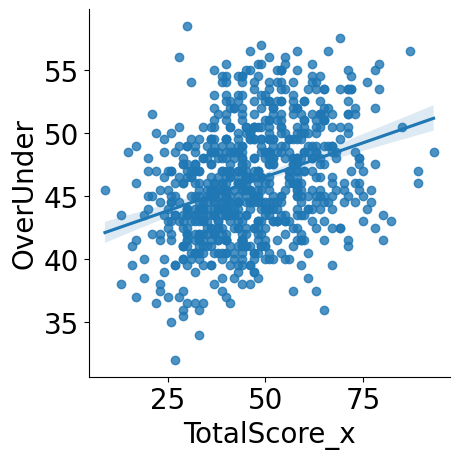

In [48]:
#OverUnder from pregame consesnus odds to Total Score - actual score
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
sns.lmplot(x='TotalScore_x',y='OverUnder',data=NFLdataset)

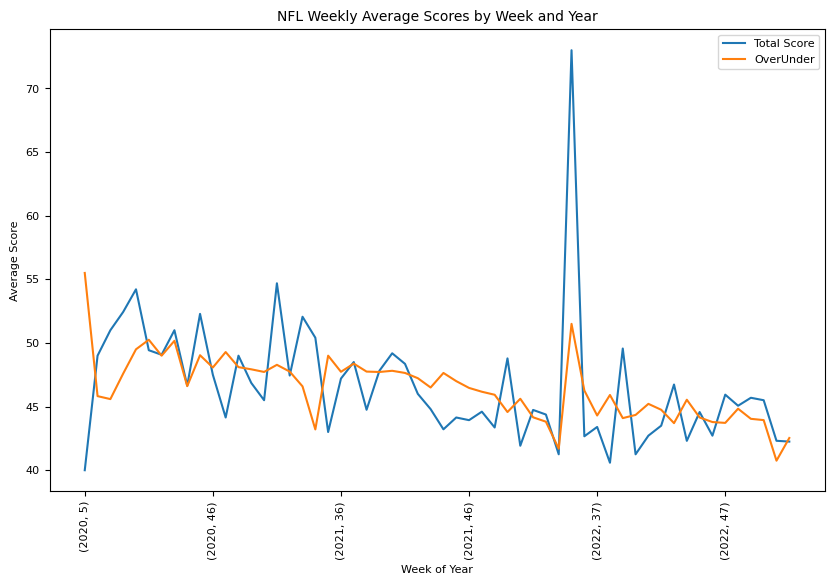

In [49]:
# group by season and week number and calculate the average score
weekly_avg_score = NFLdataset.groupby(['Season_x', 'weekofyear'])['TotalScore_x','OverUnder'].mean()

#plot the data
fig, ax = plt.subplots(figsize=(10, 6))
weekly_avg_score['TotalScore_x'].plot(kind='line', ax=ax, label='Total Score')
weekly_avg_score['OverUnder'].plot(kind='line', ax=ax, label='OverUnder')
ax.set_xlabel('Week of Year',fontsize=8)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
ax.set_ylabel('Average Score',fontsize=8)
ax.set_title('NFL Weekly Average Scores by Week and Year',fontsize=10)
plt.legend(fontsize=8)
plt.show()

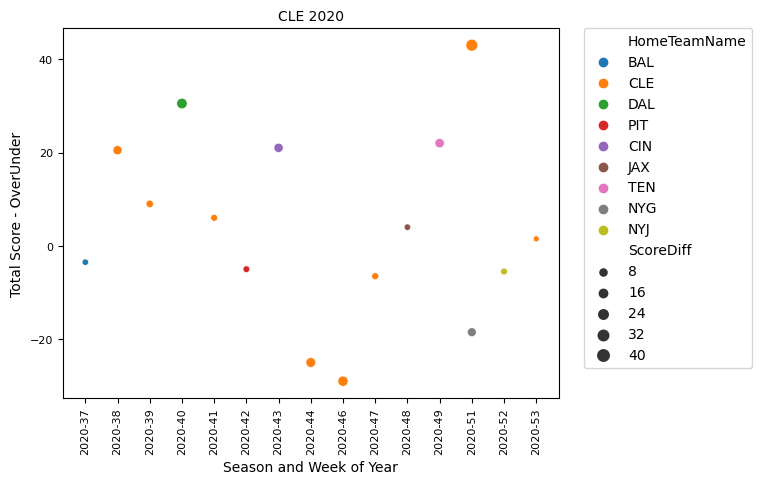

In [50]:
CLE_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'CLE') | (NFLdataset['AwayTeamName'] == 'CLE')]
CLE_games = CLE_games[(CLE_games['Season_x'] == 2020)]
CLE_games['ScoreDiff'] = CLE_games['TotalScore_x'] - CLE_games['OverUnder']

CLE_games['WeekOfYear'] = CLE_games['Season_x'].astype(str) + '-' + CLE_games['weekofyear'].astype(str)

sns.scatterplot(data=CLE_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(CLE_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('CLE 2020', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

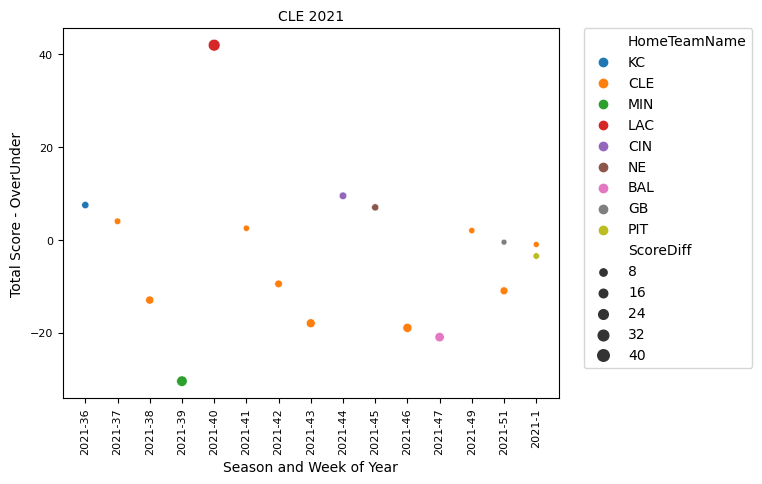

In [51]:
CLE_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'CLE') | (NFLdataset['AwayTeamName'] == 'CLE')]
CLE_games = CLE_games[(CLE_games['Season_x'] == 2021)]
CLE_games['ScoreDiff'] = CLE_games['TotalScore_x'] - CLE_games['OverUnder']

CLE_games['WeekOfYear'] = CLE_games['Season_x'].astype(str) + '-' + CLE_games['weekofyear'].astype(str)

sns.scatterplot(data=CLE_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(CLE_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('CLE 2021', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

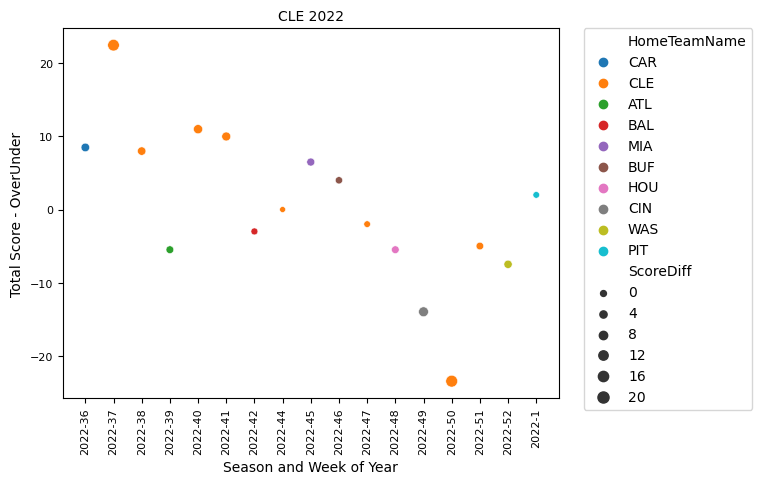

In [52]:
CLE_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'CLE') | (NFLdataset['AwayTeamName'] == 'CLE')]
CLE_games = CLE_games[(CLE_games['Season_x'] == 2022)]
CLE_games['ScoreDiff'] = CLE_games['TotalScore_x'] - CLE_games['OverUnder']

CLE_games['WeekOfYear'] = CLE_games['Season_x'].astype(str) + '-' + CLE_games['weekofyear'].astype(str)

sns.scatterplot(data=CLE_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(CLE_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('CLE 2022', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

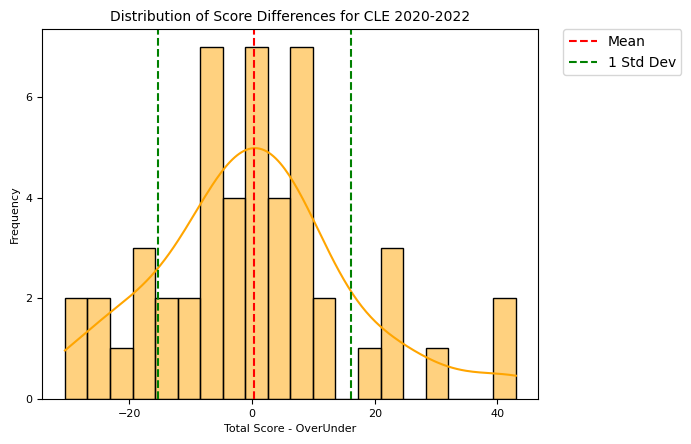

Mean score difference: 0.37
Standard deviation of score difference: 15.77
One standard deviation from the mean: -15.40 to 16.14
Two Standard deviation of score difference: 31.54
Two standard deviations from the mean: -31.17 to 31.91


In [53]:
# Calculate score differences for all CLE Game
CLE_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'CLE') | (NFLdataset['AwayTeamName'] == 'CLE')]
CLE_games['ScoreDiff'] = CLE_games['TotalScore_x'] - CLE_games['OverUnder']

score_diff_mean = np.mean(CLE_games['ScoreDiff'])
score_diff_std = np.std(CLE_games['ScoreDiff'])

sns.histplot(data=CLE_games, x='ScoreDiff', bins=20, kde=True, color='orange')
plt.xlabel('Total Score - OverUnder', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for CLE 2020-2022', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(CLE_games['ScoreDiff'])
std_dev = np.std(CLE_games['ScoreDiff'])

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

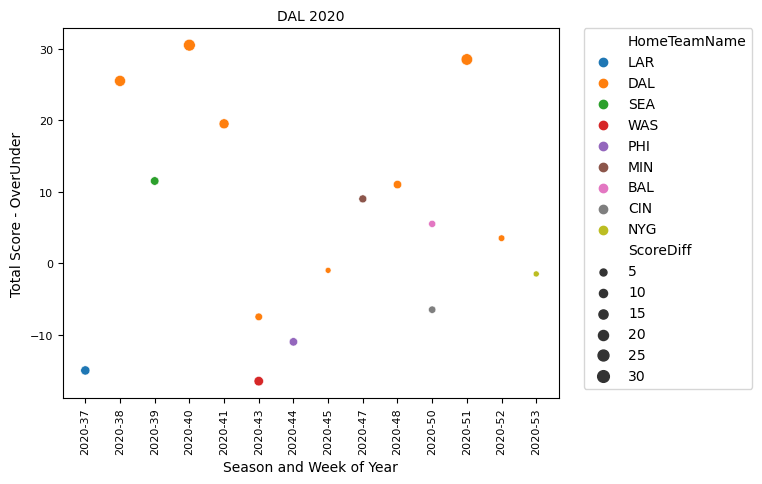

In [54]:
DAL_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'DAL') | (NFLdataset['AwayTeamName'] == 'DAL')]
DAL_games = DAL_games[(DAL_games['Season_x'] == 2020)]
DAL_games['ScoreDiff'] = DAL_games['TotalScore_x'] - DAL_games['OverUnder']

DAL_games['WeekOfYear'] = DAL_games['Season_x'].astype(str) + '-' + DAL_games['weekofyear'].astype(str)

sns.scatterplot(data=DAL_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(DAL_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('DAL 2020', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

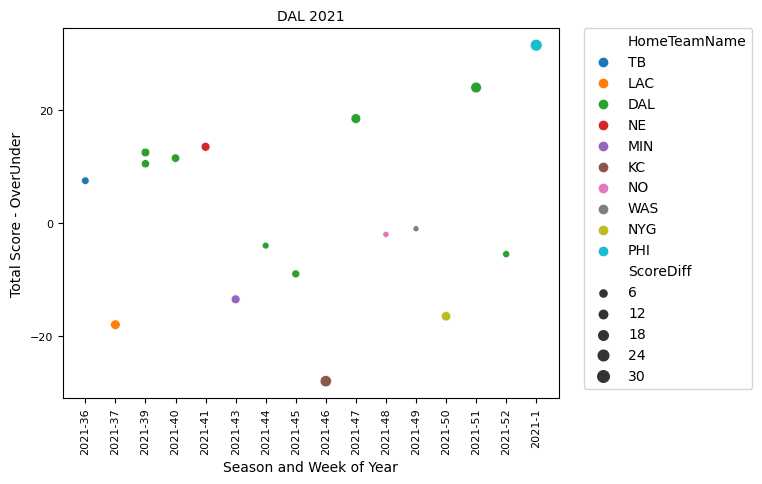

In [55]:
DAL_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'DAL') | (NFLdataset['AwayTeamName'] == 'DAL')]
DAL_games = DAL_games[(DAL_games['Season_x'] == 2021)]
DAL_games['ScoreDiff'] = DAL_games['TotalScore_x'] - DAL_games['OverUnder']

DAL_games['WeekOfYear'] = DAL_games['Season_x'].astype(str) + '-' + DAL_games['weekofyear'].astype(str)

sns.scatterplot(data=DAL_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(DAL_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('DAL 2021', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

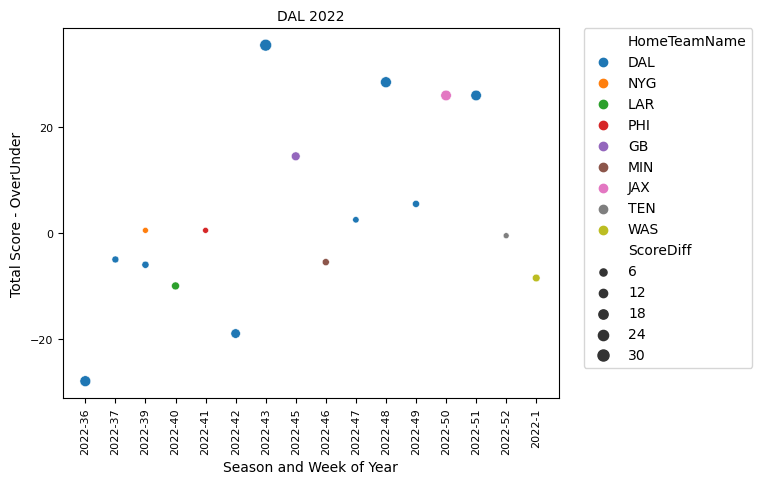

In [56]:
DAL_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'DAL') | (NFLdataset['AwayTeamName'] == 'DAL')]
DAL_games = DAL_games[(DAL_games['Season_x'] == 2022)]
DAL_games['ScoreDiff'] = DAL_games['TotalScore_x'] - DAL_games['OverUnder']

DAL_games['WeekOfYear'] = DAL_games['Season_x'].astype(str) + '-' + DAL_games['weekofyear'].astype(str)

sns.scatterplot(data=DAL_games, x='WeekOfYear', y='ScoreDiff', hue='HomeTeamName', size=abs(DAL_games['ScoreDiff']))
plt.xlabel('Season and Week of Year')
plt.xlabel('Season and Week of Year', fontsize=10)
plt.ylabel('Total Score - OverUnder', fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.title('DAL 2022', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

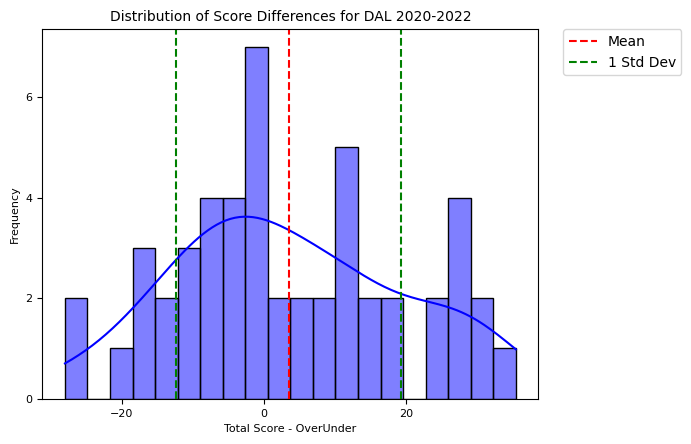

Mean score difference: 3.49
Standard deviation of score difference: 15.86
One standard deviation from the mean: -12.37 to 19.35
Two Standard deviation of score difference: 31.73
Two standard deviations from the mean: -28.24 to 35.22


In [57]:
# Calculate score differences for all CLE Game
DAL_games = NFLdataset[(NFLdataset['HomeTeamName'] == 'DAL') | (NFLdataset['AwayTeamName'] == 'DAL')]
DAL_games['ScoreDiff'] = DAL_games['TotalScore_x'] - DAL_games['OverUnder']

score_diff_mean = np.mean(DAL_games['ScoreDiff'])
score_diff_std = np.std(DAL_games['ScoreDiff'])

sns.histplot(data=DAL_games, x='ScoreDiff', bins=20, kde=True, color='blue')
plt.xlabel('Total Score - OverUnder', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for DAL 2020-2022', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(DAL_games['ScoreDiff'])
std_dev = np.std(DAL_games['ScoreDiff'])

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

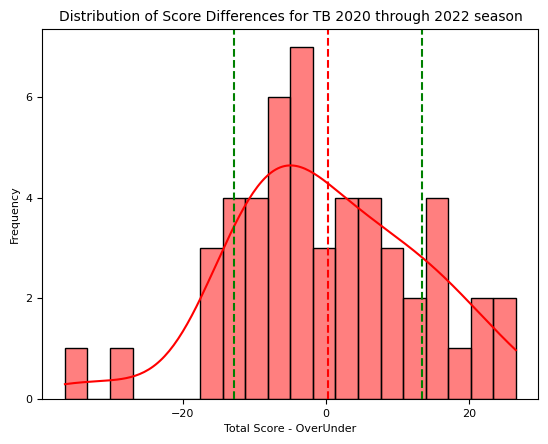

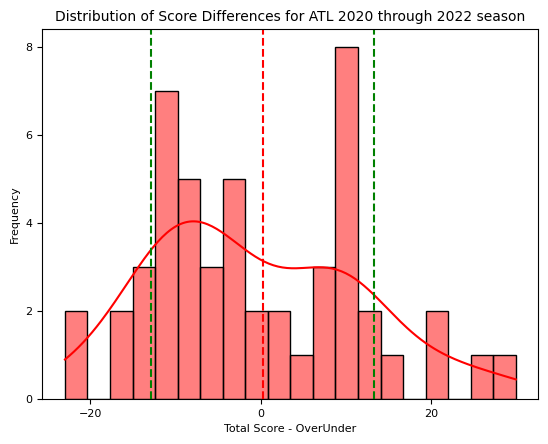

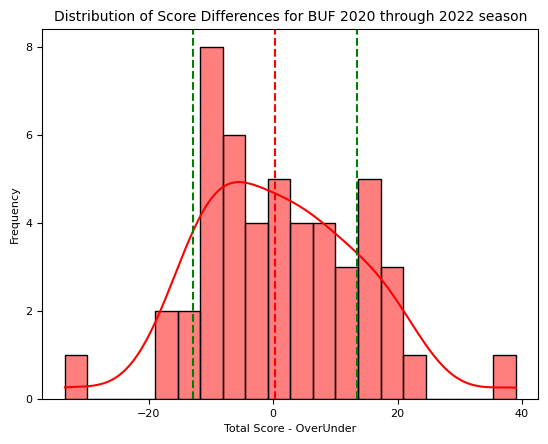

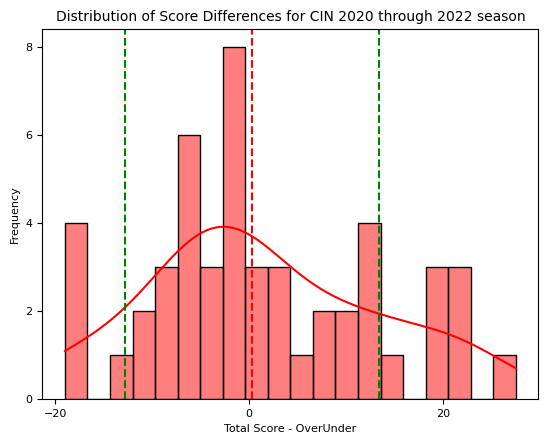

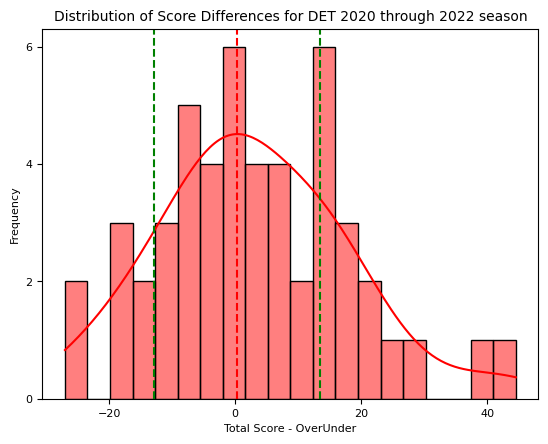

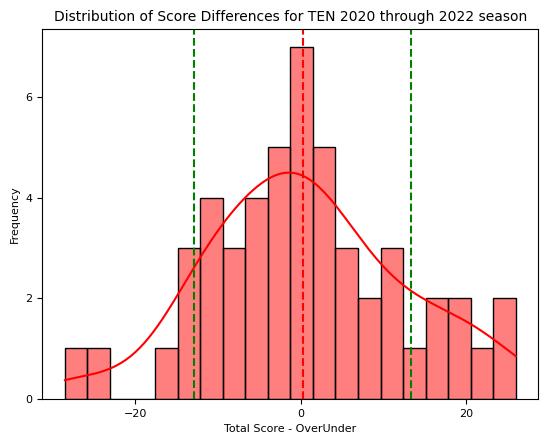

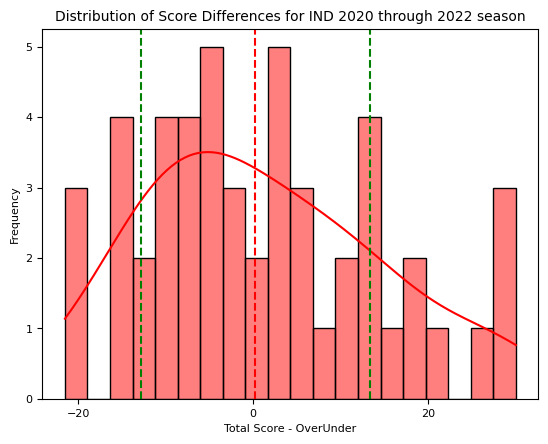

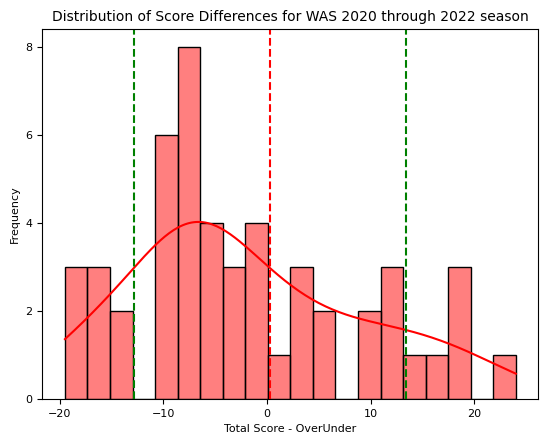

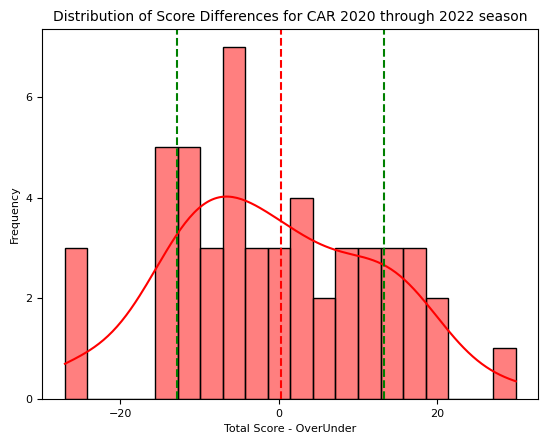

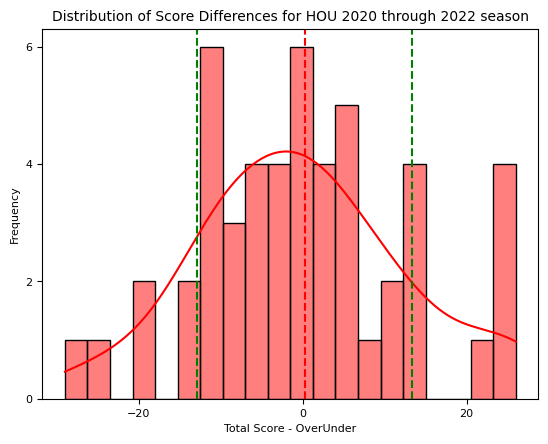

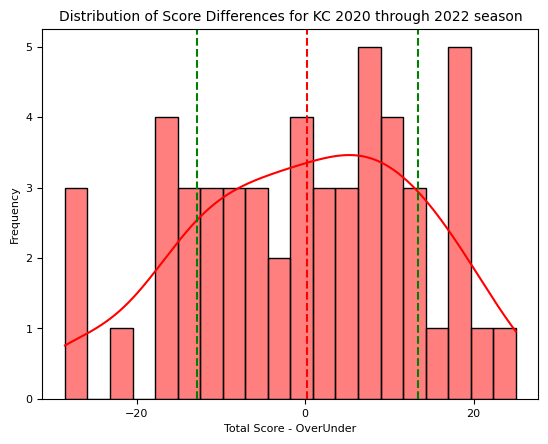

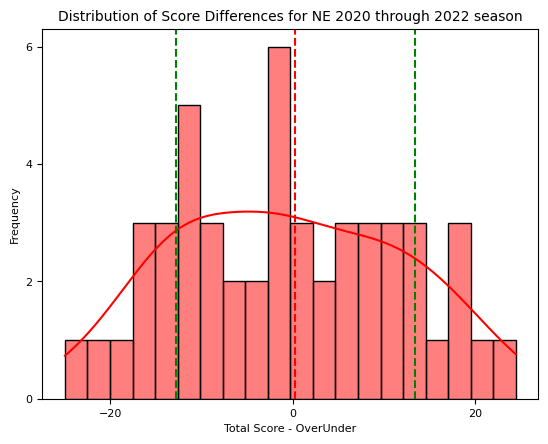

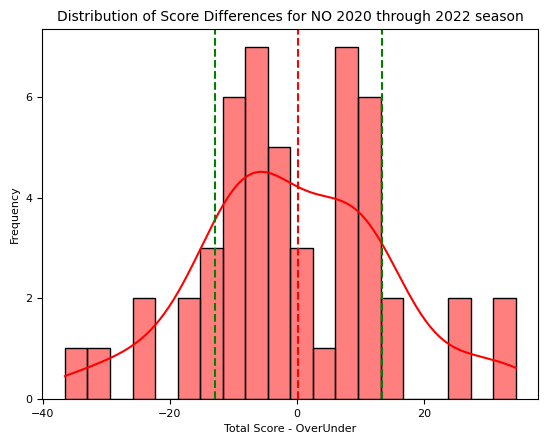

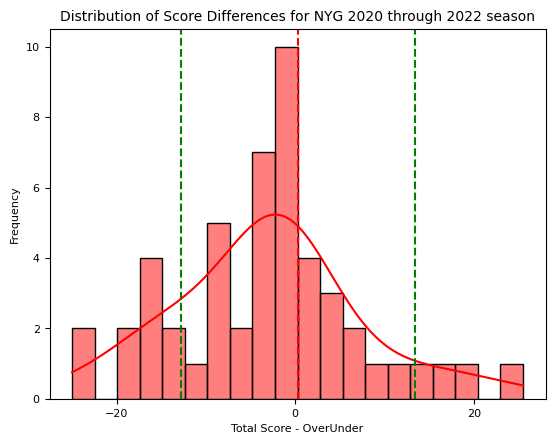

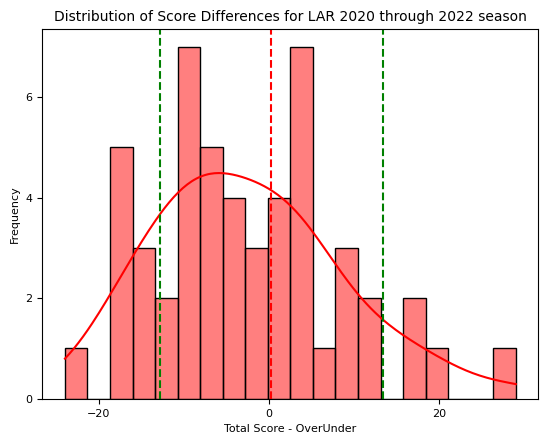

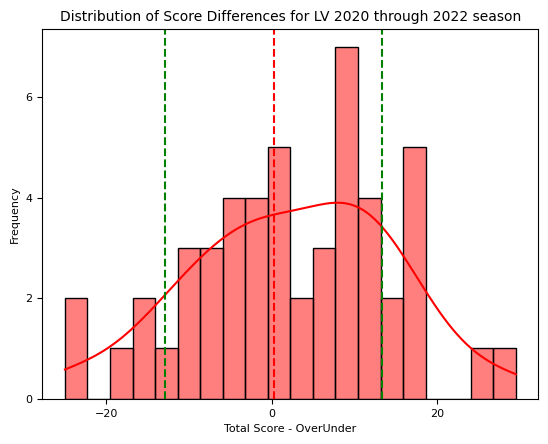

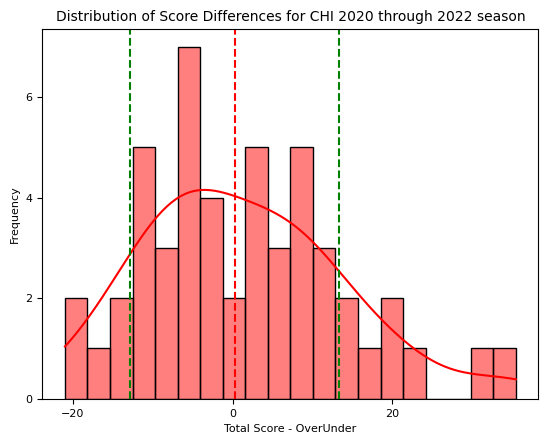

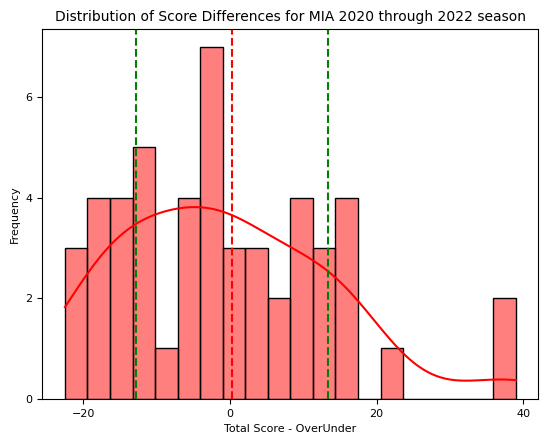

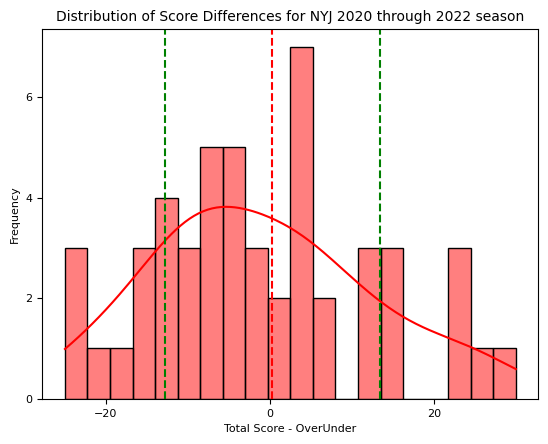

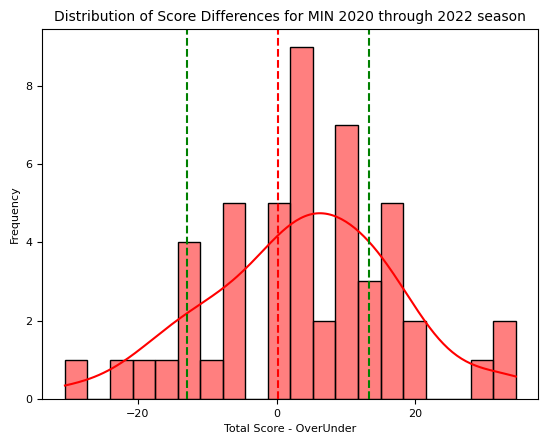

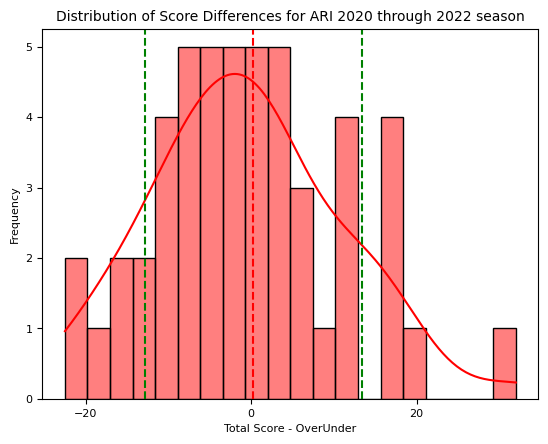

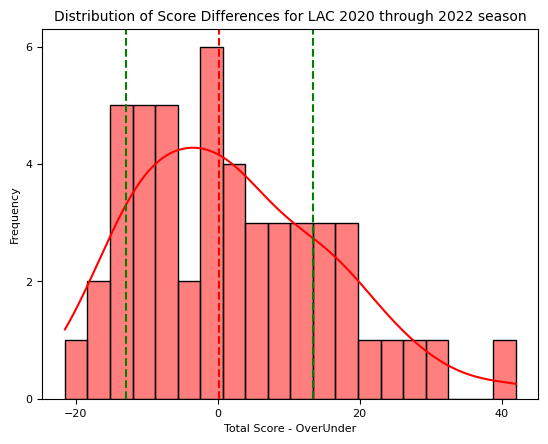

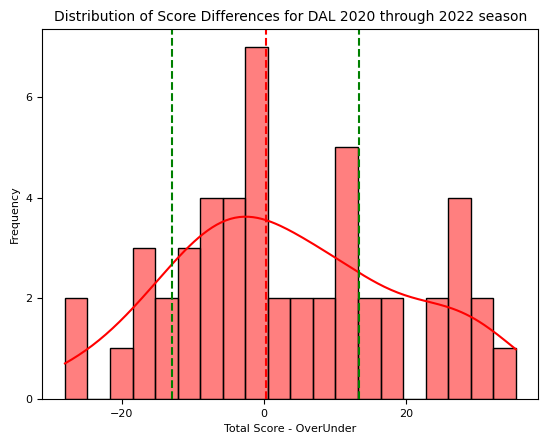

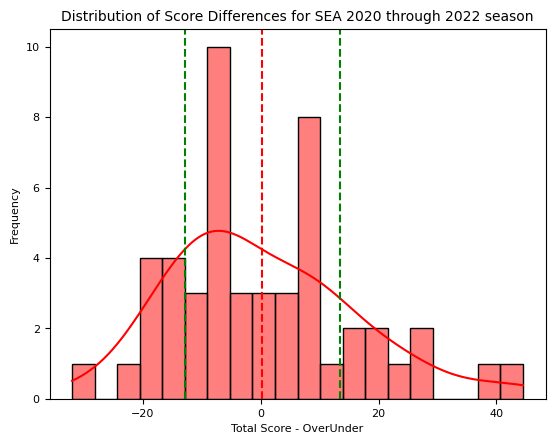

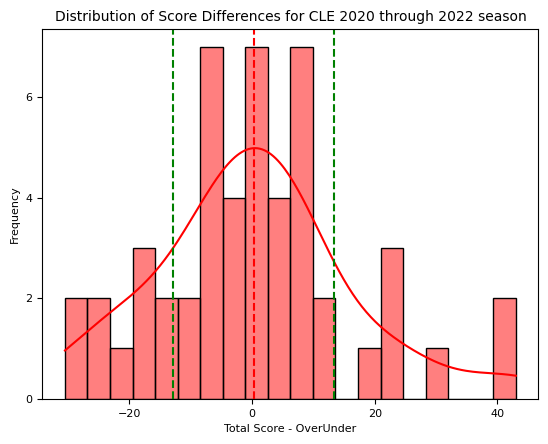

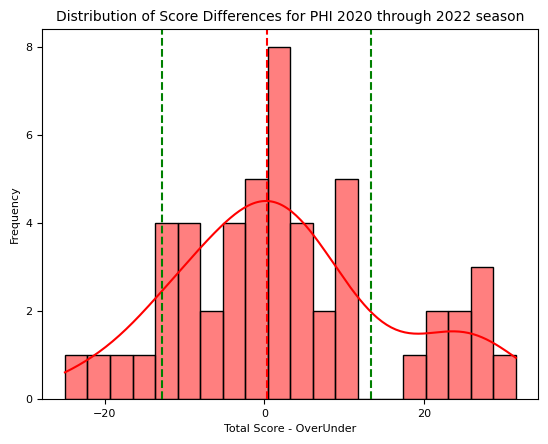

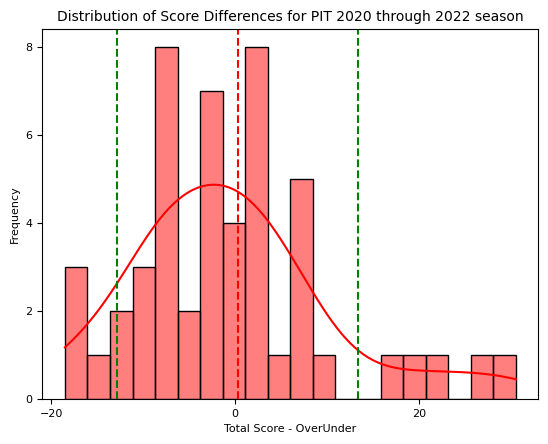

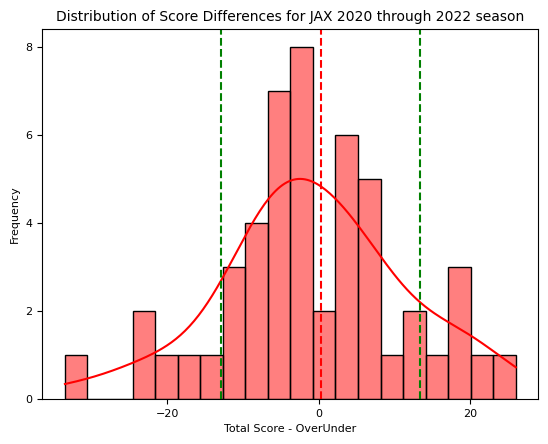

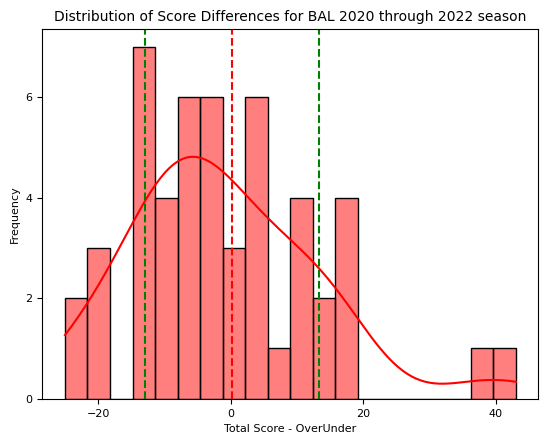

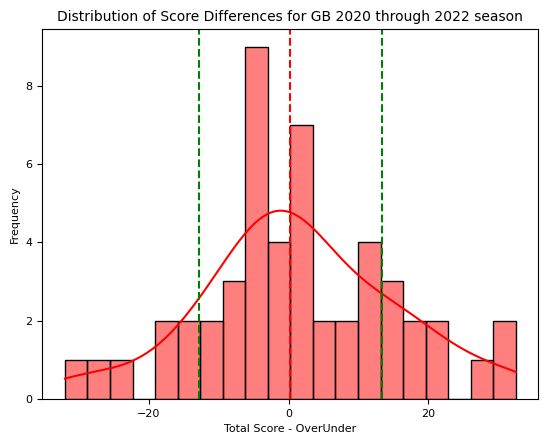

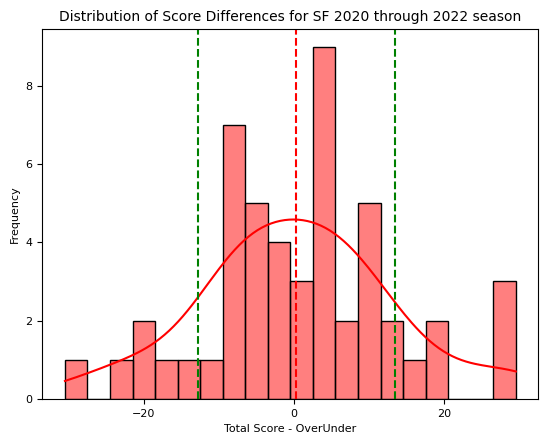

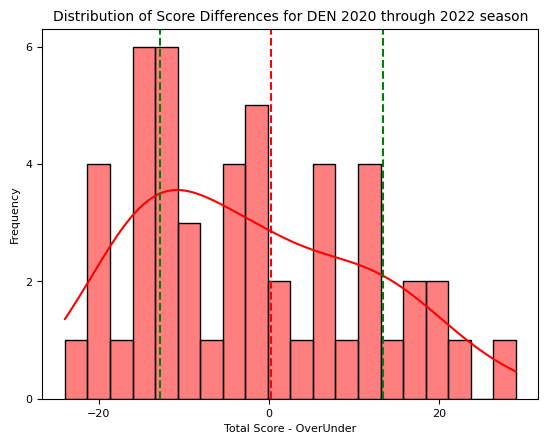

In [58]:
# Combine data from both columns into a single series
all_teams = pd.concat([NFLdataset['HomeTeamName'], NFLdataset['AwayTeamName']])

# Calculate score differences for all games
NFLdataset['ScoreDiff'] = NFLdataset['TotalScore_x'] - NFLdataset['OverUnder']
score_diff_mean = np.mean(NFLdataset['ScoreDiff'])
score_diff_std = np.std(NFLdataset['ScoreDiff'])


# Loop over each team and generate a histogram of their score differences
for team in all_teams.unique():
    team_games = NFLdataset[(NFLdataset['HomeTeamName'] == team) | (NFLdataset['AwayTeamName'] == team)]
    sns.histplot(data=team_games, x='ScoreDiff', bins=20, kde=True, color='red')
    plt.xlabel('Total Score - OverUnder', fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
    plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
    plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
    plt.title(f'Distribution of Score Differences for {team} 2020 through 2022 season', fontsize=10)
    plt.show()

In [59]:
# Create a new dataframe to store the team-wise statistics
team_stats_df = pd.DataFrame(columns=['Team', 'Mean', 'Std Dev', '1 Std Dev Below Mean', '1 Std Dev Above Mean', '2 Std Dev Below Mean', '2 Std Dev Above Mean', 'Delta > 0 Count', 'Delta < 0 Count', 'Delta = 0 Count'])

# Iterate through each team
for team in NFLdataset['HomeTeamName'].unique():
    # Create a mask to filter games by the current team
    team_mask = (NFLdataset['HomeTeamName'] == team) | (NFLdataset['AwayTeamName'] == team)
    # Calculate score differences for the current team's games
    score_diffs = NFLdataset[team_mask]['TotalScore_x'] - NFLdataset[team_mask]['OverUnder']
    # Calculate mean and standard deviation of score differences
    mean = np.mean(score_diffs)
    std_dev = np.std(score_diffs)
    # Calculate one and two standard deviations from the mean
    one_std_below = mean - std_dev
    one_std_above = mean + std_dev
    two_std_below = mean - 2*std_dev
    two_std_above = mean + 2*std_dev
    # Calculate number of deltas greater than, less than, and equal to zero
    delta_gt_0_count = np.sum(score_diffs > 0)
    delta_lt_0_count = np.sum(score_diffs < 0)
    delta_eq_0_count = np.sum(score_diffs == 0)
    # Append the team-wise statistics to the new dataframe
    team_stats_df = team_stats_df.append({'Team': team, 'Mean': mean, 'Std Dev': std_dev,
                                          '1 Std Dev Below Mean': one_std_below, '1 Std Dev Above Mean': one_std_above,
                                          '2 Std Dev Below Mean': two_std_below, '2 Std Dev Above Mean': two_std_above,
                                          'Delta > 0 Count': delta_gt_0_count, 'Delta < 0 Count': delta_lt_0_count,
                                          'Delta = 0 Count': delta_eq_0_count},
                                         ignore_index=True)

team_stats_df

#positive number means total score is greater than over under

,Team,Mean,Std Dev,1 Std Dev Below Mean,1 Std Dev Above Mean,2 Std Dev Below Mean,2 Std Dev Above Mean,Delta > 0 Count,Delta < 0 Count,Delta = 0 Count
0,TB,-0.05,12.96,-13.01,12.91,-25.97,25.87,24,27,0
1,ATL,-0.54,12.18,-12.72,11.64,-24.90,23.82,21,29,0
2,BUF,1.02,13.00,-11.98,14.02,-24.97,27.01,25,23,1
3,CIN,1.45,11.69,-10.24,13.14,-21.93,24.83,22,27,1
4,DET,2.96,14.91,-11.95,17.87,-26.86,32.78,27,23,0
5,TEN,0.51,11.74,-11.23,12.25,-22.96,23.98,25,24,1
6,IND,1.10,13.23,-12.13,14.33,-25.35,27.55,24,26,0
7,WAS,-1.95,10.88,-12.83,8.93,-23.71,19.81,17,32,1
8,CAR,-0.70,12.67,-13.37,11.97,-26.04,24.64,23,26,1
9,HOU,-0.17,12.56,-12.73,12.39,-25.30,24.96,23,27,0


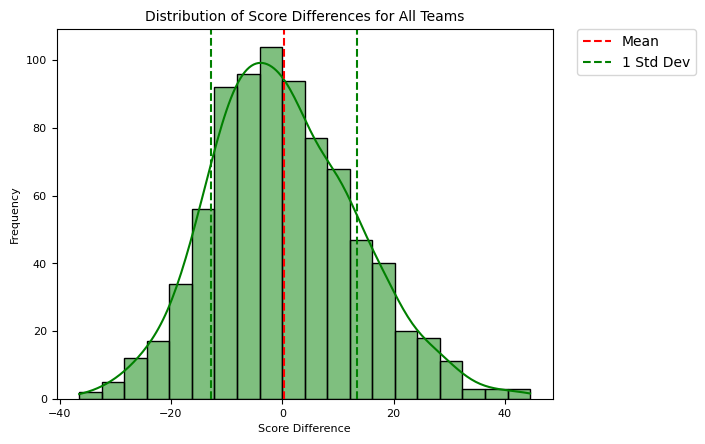

Mean score difference: 0.26
Standard deviation of score difference: 13.12
One standard deviation from the mean: -12.86 to 13.38
Two Standard deviation of score difference: 26.23
Two standard deviations from the mean: -25.97 to 26.50


In [60]:
# Calculate score differences for all games
NFLdataset['ScoreDiff'] = NFLdataset['TotalScore_x'] - NFLdataset['OverUnder']

score_diff_mean = np.mean(NFLdataset['ScoreDiff'])
score_diff_std = np.std(NFLdataset['ScoreDiff'])

sns.histplot(data=NFLdataset, x='ScoreDiff', bins=20, kde=True, color='green')
plt.xlabel('Score Difference', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for All Teams', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(NFLdataset['ScoreDiff'])
std_dev = np.std(NFLdataset['ScoreDiff'])

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

In [61]:
# Calculate score differences for all games
NFLdataset['ScoreDiff'] = NFLdataset['TotalScore_x'] - NFLdataset['OverUnder']

# Count number of positive and negative deltas
num_pos_deltas = len(NFLdataset[NFLdataset['ScoreDiff'] > 0])
num_neg_deltas = len(NFLdataset[NFLdataset['ScoreDiff'] < 0])
num_equal_deltas = len(NFLdataset[NFLdataset['ScoreDiff'] == 0])

print(f'Number of times Total Score > OverUnder: {num_pos_deltas}')
print(f'Number of times Total Score < OverUnder: {num_neg_deltas}')
print(f'Number of times Total Score = OverUnder: {num_equal_deltas}')

Number of times Total Score > OverUnder: 374
Number of times Total Score < OverUnder: 418
Number of times Total Score = OverUnder: 10


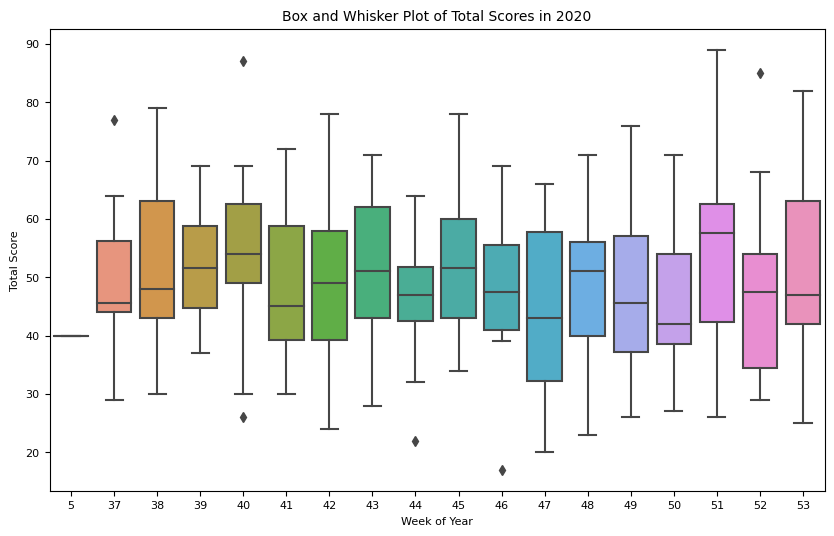

In [62]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a box and whisker plot for 2020
sns.boxplot(x='weekofyear', y='TotalScore_x', data=NFLdataset[NFLdataset['Season_x']==2020])
plt.xlabel('Week of Year', fontsize=8)
plt.ylabel('Total Score', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Box and Whisker Plot of Total Scores in 2020',fontsize=10)

# Show the plot
plt.show()

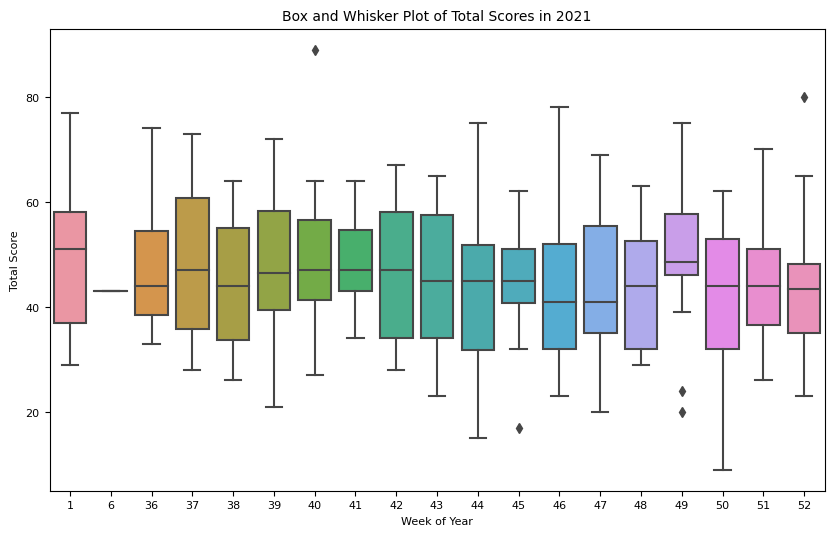

In [63]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a box and whisker plot for 2021
sns.boxplot(x='weekofyear', y='TotalScore_x', data=NFLdataset[NFLdataset['Season_x']==2021])
plt.xlabel('Week of Year', fontsize=8)
plt.ylabel('Total Score', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Box and Whisker Plot of Total Scores in 2021',fontsize=10)

# Show the plot
plt.show()

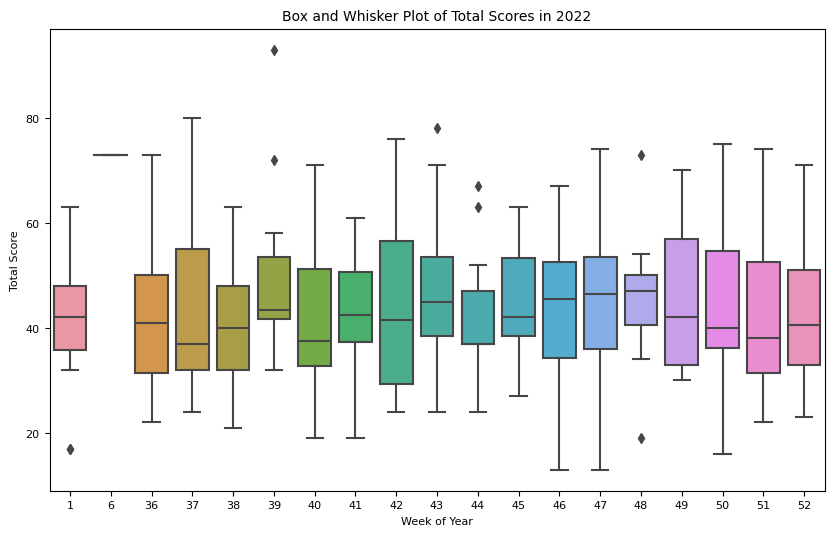

In [64]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a box and whisker plot for 2022

sns.boxplot(x='weekofyear', y='TotalScore_x', data=NFLdataset[NFLdataset['Season_x']==2022])
plt.xlabel('Week of Year', fontsize=8)
plt.ylabel('Total Score', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Box and Whisker Plot of Total Scores in 2022', fontsize=10)

# Show the plot
plt.show()

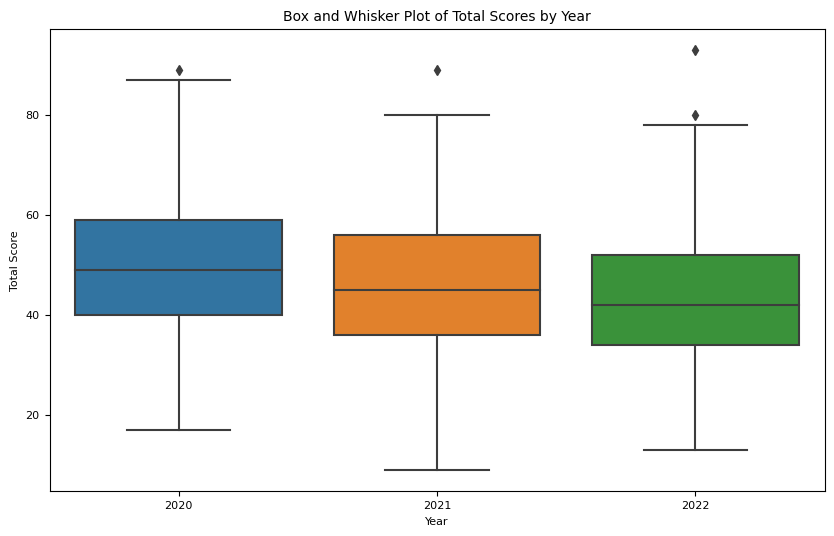

In [65]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a box and whisker plot for all three years
sns.boxplot(x='Season_x', y='TotalScore_x', data=NFLdataset, order=[2020, 2021, 2022])
plt.xlabel('Year',fontsize=8)
plt.ylabel('Total Score',fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Box and Whisker Plot of Total Scores by Year',fontsize=10)

# Show the plot
plt.show()

# Train the data for Regressions

In [66]:
#split the data into training and testing
X = NFLmodeldata.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName'],axis=1)
y = NFLmodeldata['TotalScore_x']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [67]:
# Get the column names
col_names = X.columns

# Create a DataFrame from the column names
df_col_names = pd.DataFrame(col_names, columns=['Column Names'])

# Set maximum rows to display to None
pd.set_option('display.max_rows', None)

# Reset display option to default
#pd.reset_option('display.max_rows')

# Display the DataFrame
df_col_names

#took out RedZoneConversions - left in RedZone Percantage

,Column Names
0,Season_x
1,SeasonType_x
2,Week_x
3,AwayTeamId
4,HomeTeamId
5,HomeMoneyLine
6,AwayMoneyLine
7,HomePointSpread
8,AwayPointSpread
9,HomePointSpreadPayout


# Optimal model using lazypredict

In [ ]:
#https://pypi.org/project/lazypredict/

In [68]:
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

100%|██████████| 42/42 [00:18<00:00,  2.22it/s]

                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
LassoCV                                     -0.65       0.80  5.98        1.13
ElasticNetCV                                -0.74       0.79  6.14        0.56
LassoLarsCV                                 -0.80       0.79  6.24        0.21
RidgeCV                                     -0.80       0.79  6.25        0.04
LassoLarsIC                                 -0.80       0.79  6.25        0.06
BayesianRidge                               -0.80       0.79  6.26        0.04
SGDRegressor                                -0.81       0.79  6.27        0.06
PoissonRegressor                            -0.81       0.78  6.27        0.06
Ridge                                       -0.89       0.78  6.41        0.02
LinearRegression                            -0.92       0.77  6.45        0.03
TransformedTargetRegressor                  -0.92   

# Parameter optimization for total score prediction using LassoCV

In [69]:
#train the model
lasso_cv = LassoCV()

lasso_cv.fit(X_train, y_train)

LassoCV()

In [70]:
#making a predictoion
y_pred = lasso_cv.predict(X_test)

In [71]:
#Mean Squared Error (MSE) is a measure of the average difference between the estimated and actual values. It is calculated by taking the mean of the squared differences between the estimated and actual values. MSE is a measure of how well the model fits the data, and a lower MSE indicates a better fit.
#scoring the model
Lscore = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', Lscore)

#calc mean absolute error
Lmae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', Lmae)

# Calculate R-squared
from sklearn.metrics import r2_score
Lr2 = r2_score(y_test, y_pred)
print('R2:', Lr2)

# Root Mean Squared Error (RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are, and RMSE is a measure of how spread out these residuals are. Lower values of RMSE indicate better fit.
# Calculate RMSE
Lrmsets = mean_squared_error(y_test, y_pred)**0.5
print('Root Mean Squared Error:', Lrmsets)

Mean Squared Error: 41.376233314804665
Mean Absolute Error: 5.055008302019177
R2: 0.7734744419508177
Root Mean Squared Error: 6.4324360327021255


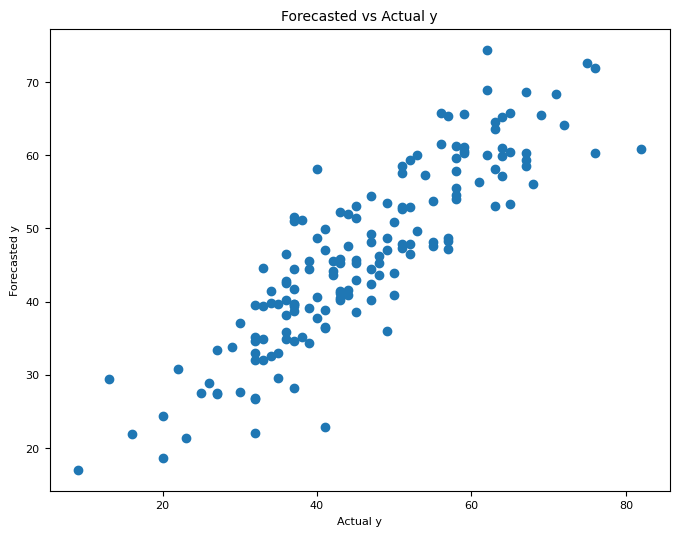

In [72]:
# Set the figure size
plt.figure(figsize=(8, 6))

#plot forecasted vs actual
plt.scatter(y_test, y_pred)
plt.xlabel('Actual y', fontsize = 8)
plt.ylabel('Forecasted y', fontsize = 8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Forecasted vs Actual y',fontsize = 10)
plt.show()

In [73]:
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate root mean squared error
rmse = np.sqrt(mse)

# Calculate standard deviation of deltas
delta_stdl = np.std(y_test - y_pred)

print(f"Standard deviation of deltas: {delta_stdl:.2f}")

Standard deviation of deltas: 6.42


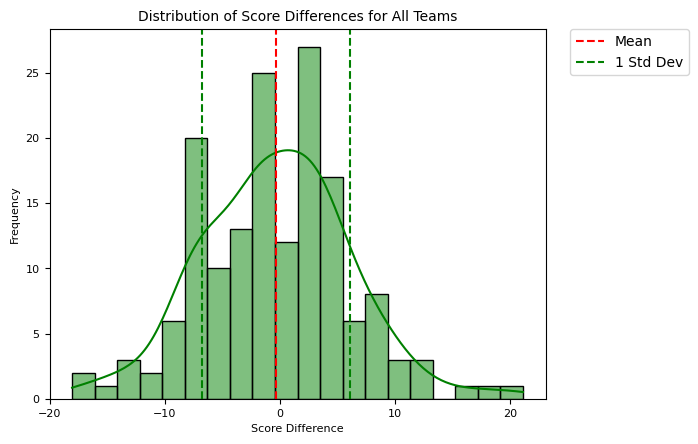

Mean score difference: -0.35
Standard deviation of score difference: 6.42
One standard deviation from the mean: -6.77 to 6.08
Two Standard deviation of score difference: 12.85
Two standard deviations from the mean: -13.19 to 12.50


In [74]:
# Calculate score differences for all games
score_diffs = y_test - y_pred

score_diff_mean = np.mean(score_diffs)
score_diff_std = np.std(score_diffs)

sns.histplot(data=score_diffs, bins=20, kde=True, color='green')
plt.xlabel('Score Difference', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for All Teams', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(score_diffs)
std_dev = np.std(score_diffs)

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

In [75]:
# Create a new dataframe to store the team-wise statistics
team_stats_df = pd.DataFrame(columns=['Team', 'Mean', 'Std Dev', '1 Std Dev Below Mean', '1 Std Dev Above Mean', '2 Std Dev Below Mean', '2 Std Dev Above Mean', 'Delta > 0 Count', 'Delta < 0 Count', 'Delta = 0 Count'])

# Iterate through each team
for team in X_test['HomeTeamId'].unique():
    # Create a mask to filter games by the current team
    team_mask = (X_test['HomeTeamId'] == team) | (X_test['AwayTeamId'] == team)
    # Calculate score differences for the current team's games
    team_X_test = X_test.loc[team_mask]
    team_y_test = y_test.loc[team_mask]
    team_y_pred = y_pred[team_mask]
    score_diffs = team_y_test - team_y_pred
    # Calculate mean and standard deviation of score differences
    mean = np.mean(score_diffs)
    std_dev = np.std(score_diffs)
    # Calculate one and two standard deviations from the mean
    one_std_below = mean - std_dev
    one_std_above = mean + std_dev
    two_std_below = mean - 2*std_dev
    two_std_above = mean + 2*std_dev
    # Calculate number of deltas greater than, less than, and equal to zero
    delta_gt_0_count = np.sum(score_diffs > 0)
    delta_lt_0_count = np.sum(score_diffs < 0)
    delta_eq_0_count = np.sum(score_diffs == 0)
    # Append the team-wise statistics to the new dataframe
    team_stats_df = team_stats_df.append({'Team': team, 'Mean': mean, 'Std Dev': std_dev,
                                          '1 Std Dev Below Mean': one_std_below, '1 Std Dev Above Mean': one_std_above,
                                          '2 Std Dev Below Mean': two_std_below, '2 Std Dev Above Mean': two_std_above,
                                          'Delta > 0 Count': delta_gt_0_count, 'Delta < 0 Count': delta_lt_0_count,
                                          'Delta = 0 Count': delta_eq_0_count},
                                         ignore_index=True)

# Create a dictionary of team IDs and names
team_names = {1: 'ARI', 2: 'ATL', 3: 'BAL', 4: 'BUF', 5: 'CAR', 6: 'CHI', 7: 'CIN', 8: 'CLE', 9: 'DAL', 10: 'DEN',
              11: 'DET', 12: 'GB', 13: 'HOU', 14: 'IND', 15: 'JAX', 16: 'KC', 19: 'MIA', 20: 'MIN', 21: 'NE',
              22: 'NO', 23: 'NYG', 24: 'NYJ', 25: 'LV', 26: 'PHI', 28: 'PIT', 29: 'LAC', 30: 'SEA', 31: 'SF',
              32: 'LAR', 33: 'TB', 34: 'TEN', 35: 'WAS'}

# Replace team IDs with team names in the team_stats_df DataFrame
team_stats_df['Team'] = team_stats_df['Team'].map(team_names)

# Print the updated DataFrame
team_stats_df

#positive number means actual is greater than prediction

,Team,Mean,Std Dev,1 Std Dev Below Mean,1 Std Dev Above Mean,2 Std Dev Below Mean,2 Std Dev Above Mean,Delta > 0 Count,Delta < 0 Count,Delta = 0 Count
0,NE,0.20,5.53,-5.33,5.74,-10.87,11.27,8.00,6.00,0.00
1,BUF,2.73,8.89,-6.16,11.61,-15.04,20.50,3.00,4.00,0.00
2,CHI,-0.84,5.84,-6.68,5.00,-12.51,10.83,6.00,6.00,0.00
3,DAL,-0.60,5.98,-6.58,5.39,-12.57,11.37,4.00,6.00,0.00
4,DEN,0.96,5.36,-4.40,6.32,-9.76,11.68,5.00,6.00,0.00
5,IND,0.00,4.84,-4.84,4.84,-9.68,9.68,7.00,3.00,0.00
6,SF,-0.92,5.99,-6.91,5.07,-12.89,11.06,5.00,6.00,0.00
7,NYJ,-1.29,4.30,-5.58,3.01,-9.88,7.31,5.00,7.00,0.00
8,CAR,-0.14,5.08,-5.22,4.94,-10.30,10.03,4.00,8.00,0.00
9,JAX,-2.34,8.05,-10.39,5.71,-18.45,13.77,3.00,6.00,0.00


# Parameter optimization for total score prediction using OrthogonalMatchingPursuitCV

In [76]:
param_grid = {
    'copy': [True, False],
    'cv': [3, 5, 7],
    'fit_intercept': [True, False],
    'max_iter': [15, 20, 27],
    'n_jobs': [1, -1],
    'normalize': [True, False],
    'verbose': [True, False]
}

In [77]:
#build the model, verbose to 3 shows it going through all 500 fits
model = OrthogonalMatchingPursuitCV()
grid = RandomizedSearchCV(model, param_grid, verbose=0, n_iter=100)
grid.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_j

RandomizedSearchCV(estimator=OrthogonalMatchingPursuitCV(), n_iter=100,
                   param_distributions={'copy': [True, False], 'cv': [3, 5, 7],
                                        'fit_intercept': [True, False],
                                        'max_iter': [15, 20, 27],
                                        'n_jobs': [1, -1],
                                        'normalize': [True, False],
                                        'verbose': [True, False]})

In [78]:
# these are the parameters used in the next setting
grid.best_params_ 

{'verbose': False,
 'normalize': True,
 'n_jobs': -1,
 'max_iter': 27,
 'fit_intercept': True,
 'cv': 7,
 'copy': False}

In [79]:
#build the model
test = OrthogonalMatchingPursuitCV(**grid.best_params_)
test.fit(X_train, y_train)

#predict the values
y_pred = test.predict(X_test)

In [80]:
#Mean Squared Error (MSE) is a measure of the average difference between the estimated and actual values. It is calculated by taking the mean of the squared differences between the estimated and actual values. MSE is a measure of how well the model fits the data, and a lower MSE indicates a better fit.
#scoring the model
Oscore = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', Oscore)

#calc mean absolute error
Omae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', Omae)

# Calculate R-squared
from sklearn.metrics import r2_score
Or2 = r2_score(y_test, y_pred)
print('R2:', Or2)

# Root Mean Squared Error (RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are, and RMSE is a measure of how spread out these residuals are. Lower values of RMSE indicate better fit.
# Calculate RMSE
Ormsets = mean_squared_error(y_test, y_pred)**0.5
print('Root Mean Squared Error:', Ormsets)

Mean Squared Error: 39.83672134092691
Mean Absolute Error: 5.0646526664078895
R2: 0.7819029232568063
Root Mean Squared Error: 6.3116338091596305


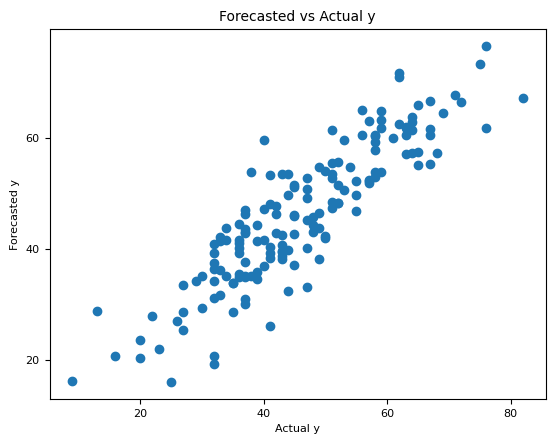

In [81]:
#plot forecasted vs actual
plt.scatter(y_test, y_pred)
plt.xlabel('Actual y', fontsize = 8)
plt.ylabel('Forecasted y', fontsize = 8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Forecasted vs Actual y',fontsize = 10)
plt.show()

In [82]:
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate root mean squared error
rmse = np.sqrt(mse)

# Calculate standard deviation of deltas
delta_stdo = np.std(y_test - y_pred)

print(f"Standard deviation of deltas: {delta_stdo:.2f}")

Standard deviation of deltas: 6.31


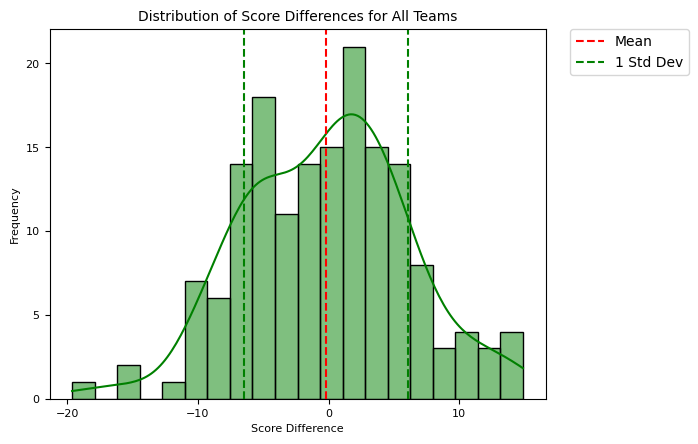

Mean score difference: -0.19
Standard deviation of score difference: 6.31
One standard deviation from the mean: -6.50 to 6.11
Two Standard deviation of score difference: 12.62
Two standard deviations from the mean: -12.81 to 12.42


In [83]:
# Calculate score differences for all games
score_diffs = y_test - y_pred

score_diff_mean = np.mean(score_diffs)
score_diff_std = np.std(score_diffs)

sns.histplot(data=score_diffs, bins=20, kde=True, color='green')
plt.xlabel('Score Difference', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for All Teams', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(score_diffs)
std_dev = np.std(score_diffs)

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

In [84]:
# Create a new dataframe to store the team-wise statistics
team_stats_df = pd.DataFrame(columns=['Team', 'Mean', 'Std Dev', '1 Std Dev Below Mean', '1 Std Dev Above Mean', '2 Std Dev Below Mean', '2 Std Dev Above Mean', 'Delta > 0 Count', 'Delta < 0 Count', 'Delta = 0 Count'])

# Iterate through each team
for team in X_test['HomeTeamId'].unique():
    # Create a mask to filter games by the current team
    team_mask = (X_test['HomeTeamId'] == team) | (X_test['AwayTeamId'] == team)
    # Calculate score differences for the current team's games
    team_X_test = X_test.loc[team_mask]
    team_y_test = y_test.loc[team_mask]
    team_y_pred = y_pred[team_mask]
    score_diffs = team_y_test - team_y_pred
    # Calculate mean and standard deviation of score differences
    mean = np.mean(score_diffs)
    std_dev = np.std(score_diffs)
    # Calculate one and two standard deviations from the mean
    one_std_below = mean - std_dev
    one_std_above = mean + std_dev
    two_std_below = mean - 2*std_dev
    two_std_above = mean + 2*std_dev
    # Calculate number of deltas greater than, less than, and equal to zero
    delta_gt_0_count = np.sum(score_diffs > 0)
    delta_lt_0_count = np.sum(score_diffs < 0)
    delta_eq_0_count = np.sum(score_diffs == 0)
    # Append the team-wise statistics to the new dataframe
    team_stats_df = team_stats_df.append({'Team': team, 'Mean': mean, 'Std Dev': std_dev,
                                          '1 Std Dev Below Mean': one_std_below, '1 Std Dev Above Mean': one_std_above,
                                          '2 Std Dev Below Mean': two_std_below, '2 Std Dev Above Mean': two_std_above,
                                          'Delta > 0 Count': delta_gt_0_count, 'Delta < 0 Count': delta_lt_0_count,
                                          'Delta = 0 Count': delta_eq_0_count},
                                         ignore_index=True)

# Create a dictionary of team IDs and names
team_names = {1: 'ARI', 2: 'ATL', 3: 'BAL', 4: 'BUF', 5: 'CAR', 6: 'CHI', 7: 'CIN', 8: 'CLE', 9: 'DAL', 10: 'DEN',
              11: 'DET', 12: 'GB', 13: 'HOU', 14: 'IND', 15: 'JAX', 16: 'KC', 19: 'MIA', 20: 'MIN', 21: 'NE',
              22: 'NO', 23: 'NYG', 24: 'NYJ', 25: 'LV', 26: 'PHI', 28: 'PIT', 29: 'LAC', 30: 'SEA', 31: 'SF',
              32: 'LAR', 33: 'TB', 34: 'TEN', 35: 'WAS'}

# Replace team IDs with team names in the team_stats_df DataFrame
team_stats_df['Team'] = team_stats_df['Team'].map(team_names)

# Print the updated DataFrame
team_stats_df

#positive number means actual is greater than prediction

,Team,Mean,Std Dev,1 Std Dev Below Mean,1 Std Dev Above Mean,2 Std Dev Below Mean,2 Std Dev Above Mean,Delta > 0 Count,Delta < 0 Count,Delta = 0 Count
0,NE,0.38,5.98,-5.60,6.37,-11.58,12.35,9.00,5.00,0.00
1,BUF,0.03,7.73,-7.70,7.76,-15.42,15.49,4.00,3.00,0.00
2,CHI,1.89,7.49,-5.59,9.38,-13.08,16.87,8.00,4.00,0.00
3,DAL,0.23,6.07,-5.83,6.30,-11.90,12.36,6.00,4.00,0.00
4,DEN,1.91,5.66,-3.74,7.57,-9.40,13.23,7.00,4.00,0.00
5,IND,0.29,4.39,-4.10,4.68,-8.48,9.07,7.00,3.00,0.00
6,SF,-0.83,6.93,-7.75,6.10,-14.68,13.03,6.00,5.00,0.00
7,NYJ,-0.25,5.16,-5.41,4.90,-10.57,10.06,6.00,6.00,0.00
8,CAR,-0.59,4.46,-5.06,3.87,-9.52,8.34,7.00,5.00,0.00
9,JAX,-1.97,8.01,-9.98,6.04,-17.99,14.05,2.00,7.00,0.00


# Parameter optimization for total score prediction XGBoost

In [85]:
#create the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'n_estimators': [100, 200, 300, 400],
    'gamma': [0, 0.5, 1, 1.5]
}

In [86]:
#build the model, verbose to 3 shows it going through all 500 fits
#model = XGBRegressor()
#grid = RandomizedSearchCV(model, param_grid, verbose=1, n_iter=100)
#grid.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, gamma=None,
                                          gpu_id=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_ca...
                                          min_child_weight=None, missing=nan,
                                          monoto

In [87]:
# these are the parameters used in the next setting
#grid.best_params_ 

{'n_estimators': 400,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0.5}

In [89]:
# Save NFLmodeldata as a pickle file
with open('grid.best_params_.pickle', 'wb') as f:
    pickle.dump(grid.best_params_, f)

In [ ]:
# Load NFLmodeldata from the pickle file
with open('grid.best_params.pickle', 'rb') as f:
        grid.best_params_ = pickle.load(f)

In [90]:
#build the model
modelts = XGBRegressor(n_estimators= 400,
                       min_child_weight= 5,
                       max_depth= 3,
                       learning_rate= 0.1,
                       gamma= 0.5)
modelts.fit(X_train, y_train)

#predict the values
y_pred = modelts.predict(X_test)

In [91]:
#Mean Squared Error (MSE) is a measure of the average difference between the estimated and actual values. It is calculated by taking the mean of the squared differences between the estimated and actual values. MSE is a measure of how well the model fits the data, and a lower MSE indicates a better fit.
#scoring the model
Xscore = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', Xscore)

#calc mean absolute error
Xmae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', Xmae)

# Calculate R-squared
from sklearn.metrics import r2_score
Xr2 = r2_score(y_test, y_pred)
print('R2:', Xr2)

# Root Mean Squared Error (RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are, and RMSE is a measure of how spread out these residuals are. Lower values of RMSE indicate better fit.
# Calculate RMSE
Xrmsets = mean_squared_error(y_test, y_pred)**0.5
print('Root Mean Squared Error:', Xrmsets)

Mean Squared Error: 48.39614005380473
Mean Absolute Error: 5.413889973800375
R2: 0.7350420336789842
Root Mean Squared Error: 6.956733432711413


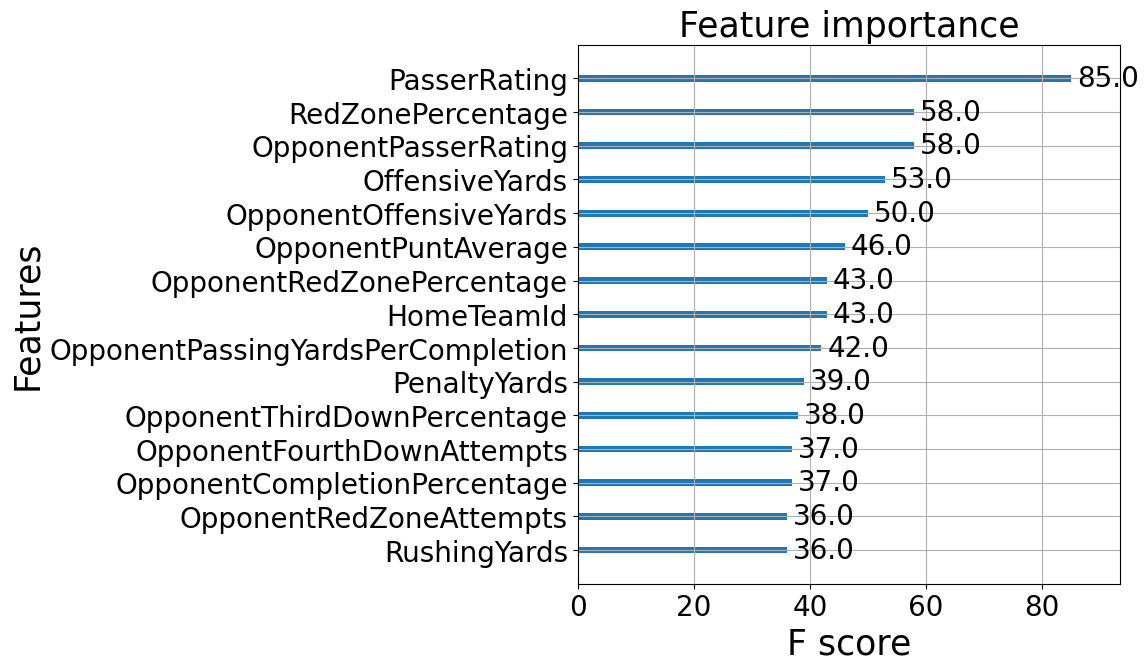

In [115]:
#Top 15 features
plt.rcParams['figure.figsize'] = [7, 7]
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['axes.titlesize'] = 25
xgb.plot_importance(modelts, max_num_features=15)
plt.show()

In [197]:
# Get feature importance scores
importance = modelts.get_booster().get_score(importance_type='weight')

# Create DataFrame of features and F scores
feature_scores_df = pd.DataFrame({'Feature': list(importance.keys()), 'F Score': list(importance.values())})

# Sort features by F score in descending order
feature_scores_df = feature_scores_df.sort_values(by='F Score', ascending=False).reset_index(drop=True)

# Print DataFrame
print(feature_scores_df)

                               Feature  F Score
0                         PasserRating    85.00
1                 OpponentPasserRating    58.00
2                    RedZonePercentage    58.00
3                       OffensiveYards    53.00
4               OpponentOffensiveYards    50.00
5                  OpponentPuntAverage    46.00
6            OpponentRedZonePercentage    43.00
7                           HomeTeamId    43.00
8    OpponentPassingYardsPerCompletion    42.00
9                         PenaltyYards    39.00
10         OpponentThirdDownPercentage    38.00
11        OpponentCompletionPercentage    37.00
12          OpponentFourthDownAttempts    37.00
13                        RushingYards    36.00
14             OpponentRedZoneAttempts    36.00
15                         PuntAverage    34.00
16                OpponentPassingYards    34.00
17                CompletionPercentage    34.00
18                   OpponentPuntYards    33.00
19      OpponentRushingYardsPerAttempt  

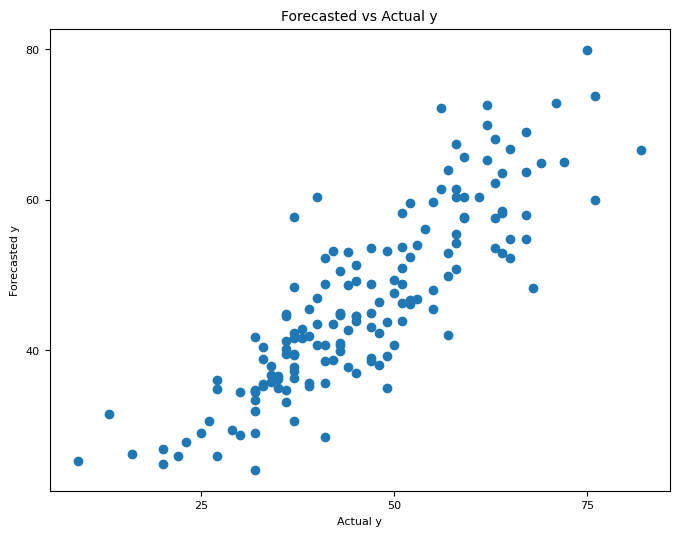

In [96]:
#predict the values
y_pred = modelts.predict(X_test)

#plot forecasted vs actual
plt.subplots(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel('Actual y',fontsize=8)
plt.ylabel('Forecasted y',fontsize=8)
plt.title('Forecasted vs Actual y',fontsize=10)
plt.show()

In [97]:
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate root mean squared error
rmse = np.sqrt(mse)

# Calculate standard deviation of deltas
delta_stdxg = np.std(y_test - y_pred)

print(f"Standard deviation of deltas: {delta_stdxg:.2f}")

Standard deviation of deltas: 6.94


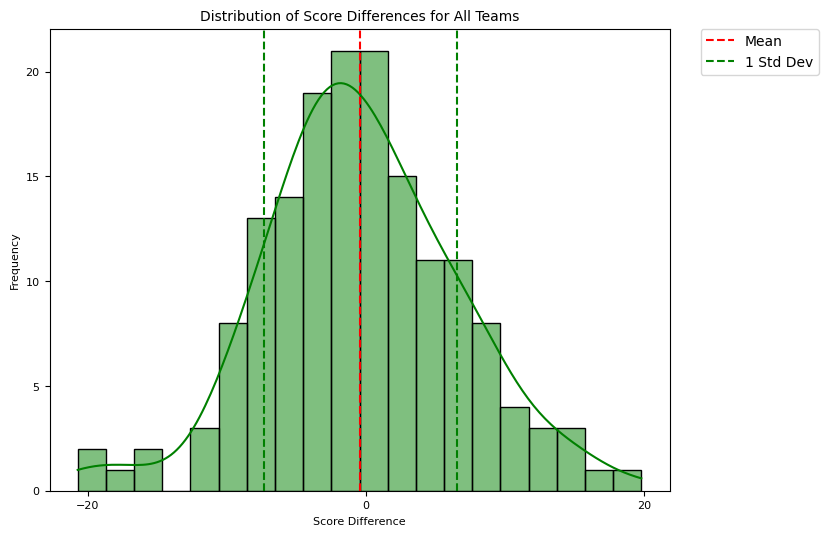

Mean score difference: -0.42
Standard deviation of score difference: 6.94
One standard deviation from the mean: -7.36 to 6.53
Two Standard deviation of score difference: 13.89
Two standard deviations from the mean: -14.31 to 13.47


In [98]:
# Calculate score differences for all games
score_diffs = y_test - y_pred

score_diff_mean = np.mean(score_diffs)
score_diff_std = np.std(score_diffs)

plt.subplots(figsize=(8, 6))
sns.histplot(data=score_diffs, bins=20, kde=True, color='green')
plt.xlabel('Score Difference', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Distribution of Score Differences for All Teams', fontsize=10)
plt.axvline(x=score_diff_mean, color='red', linestyle='--', label='Mean')
plt.axvline(x=score_diff_mean + score_diff_std, color='green', linestyle='--', label='1 Std Dev')
plt.axvline(x=score_diff_mean - score_diff_std, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=10)
plt.show()

# Calculate mean and standard deviation
mean = np.mean(score_diffs)
std_dev = np.std(score_diffs)

print(f"Mean score difference: {mean:.2f}")
print(f"Standard deviation of score difference: {std_dev:.2f}")
print(f"One standard deviation from the mean: {(mean - std_dev):.2f} to {(mean + std_dev):.2f}")
print(f"Two Standard deviation of score difference: {2*std_dev:.2f}")
print(f"Two standard deviations from the mean: {(mean - 2*std_dev):.2f} to {(mean + 2*std_dev):.2f}")

In [99]:
# Create a new dataframe to store the team-wise statistics
team_stats_df = pd.DataFrame(columns=['Team', 'Mean', 'Std Dev', '1 Std Dev Below Mean', '1 Std Dev Above Mean', '2 Std Dev Below Mean', '2 Std Dev Above Mean', 'Delta > 0 Count', 'Delta < 0 Count', 'Delta = 0 Count'])

# Iterate through each team
for team in X_test['HomeTeamId'].unique():
    # Create a mask to filter games by the current team
    team_mask = (X_test['HomeTeamId'] == team) | (X_test['AwayTeamId'] == team)
    # Calculate score differences for the current team's games
    team_X_test = X_test.loc[team_mask]
    team_y_test = y_test.loc[team_mask]
    team_y_pred = y_pred[team_mask]
    score_diffs = team_y_test - team_y_pred
    # Calculate mean and standard deviation of score differences
    mean = np.mean(score_diffs)
    std_dev = np.std(score_diffs)
    # Calculate one and two standard deviations from the mean
    one_std_below = mean - std_dev
    one_std_above = mean + std_dev
    two_std_below = mean - 2*std_dev
    two_std_above = mean + 2*std_dev
    # Calculate number of deltas greater than, less than, and equal to zero
    delta_gt_0_count = np.sum(score_diffs > 0)
    delta_lt_0_count = np.sum(score_diffs < 0)
    delta_eq_0_count = np.sum(score_diffs == 0)
    # Append the team-wise statistics to the new dataframe
    team_stats_df = team_stats_df.append({'Team': team, 'Mean': mean, 'Std Dev': std_dev,
                                          '1 Std Dev Below Mean': one_std_below, '1 Std Dev Above Mean': one_std_above,
                                          '2 Std Dev Below Mean': two_std_below, '2 Std Dev Above Mean': two_std_above,
                                          'Delta > 0 Count': delta_gt_0_count, 'Delta < 0 Count': delta_lt_0_count,
                                          'Delta = 0 Count': delta_eq_0_count},
                                         ignore_index=True)

# Create a dictionary of team IDs and names
team_names = {1: 'ARI', 2: 'ATL', 3: 'BAL', 4: 'BUF', 5: 'CAR', 6: 'CHI', 7: 'CIN', 8: 'CLE', 9: 'DAL', 10: 'DEN',
              11: 'DET', 12: 'GB', 13: 'HOU', 14: 'IND', 15: 'JAX', 16: 'KC', 19: 'MIA', 20: 'MIN', 21: 'NE',
              22: 'NO', 23: 'NYG', 24: 'NYJ', 25: 'LV', 26: 'PHI', 28: 'PIT', 29: 'LAC', 30: 'SEA', 31: 'SF',
              32: 'LAR', 33: 'TB', 34: 'TEN', 35: 'WAS'}

# Replace team IDs with team names in the team_stats_df DataFrame
team_stats_df['Team'] = team_stats_df['Team'].map(team_names)

# Print the updated DataFrame
team_stats_df

#positive number means actual is greater than prediction

,Team,Mean,Std Dev,1 Std Dev Below Mean,1 Std Dev Above Mean,2 Std Dev Below Mean,2 Std Dev Above Mean,Delta > 0 Count,Delta < 0 Count,Delta = 0 Count
0,NE,0.15,5.55,-5.41,5.70,-10.96,11.25,8.00,6.00,0.00
1,BUF,2.90,8.10,-5.20,10.99,-13.29,19.09,4.00,3.00,0.00
2,CHI,0.30,5.23,-4.93,5.53,-10.16,10.76,4.00,8.00,0.00
3,DAL,-0.58,7.47,-8.05,6.89,-15.51,14.35,6.00,4.00,0.00
4,DEN,-1.44,6.56,-8.00,5.12,-14.56,11.68,4.00,7.00,0.00
5,IND,-2.71,6.61,-9.32,3.90,-15.93,10.50,5.00,5.00,0.00
6,SF,-2.11,7.80,-9.91,5.70,-17.72,13.50,5.00,6.00,0.00
7,NYJ,-0.46,3.74,-4.20,3.28,-7.94,7.02,5.00,7.00,0.00
8,CAR,-0.58,5.42,-6.00,4.84,-11.43,10.26,5.00,7.00,0.00
9,JAX,-2.33,10.08,-12.41,7.75,-22.49,17.84,3.00,6.00,0.00


# Comparing the output of the three models - OrthogonalMatchingPursuitCV, LassoCV, XGBoost

In [100]:
data = {'Metric':['Mean Squared Error','Mean Absolute Error','R2','Root mean squared error'], 'OrthogonalMatchingPursuitCV':[Oscore,Omae,Or2,Ormsets], 'LassoCV':[Lscore,Lmae,Lr2,Lrmsets], 'XGBoost':[Xscore,Xmae,Xr2,Xrmsets]}

table = pd.DataFrame(data)

print(table)

                    Metric  OrthogonalMatchingPursuitCV  LassoCV  XGBoost
0       Mean Squared Error                        39.84    41.38    48.40
1      Mean Absolute Error                         5.06     5.06     5.41
2                       R2                         0.78     0.77     0.74
3  Root mean squared error                         6.31     6.43     6.96


# *Using XGBoost for Away Team Score*

In [101]:
#split the data into training and testing
X = NFLmodeldata.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName'],axis=1)
y = NFLmodeldata['OpponentScore']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [102]:
#create the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'n_estimators': [100, 200, 300, 400],
    'gamma': [0, 0.5, 1, 1.5]
}

In [103]:
#build the model - turned off since eit takes forever to run - 
#model = XGBRegressor()
#grid = RandomizedSearchCV(model, param_grid, verbose=1, n_iter=100)
#grid.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, gamma=None,
                                          gpu_id=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_ca...
                                          min_child_weight=None, missing=nan,
                                          monoto

In [104]:
#grid.best_params_

{'n_estimators': 300,
 'min_child_weight': 7,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 1}

In [105]:
#build the model
modelas = XGBRegressor(n_estimators=300, 
                       min_child_weight=7, 
                       max_depth=3, 
                       learning_rate=0.1, 
                       gamma=1)
modelas.fit(X_train, y_train)

#predict the values
y_pred = modelas.predict(X_test)

In [106]:
#Mean Squared Error (MSE) is a measure of the average difference between the estimated and actual values. It is calculated by taking the mean of the squared differences between the estimated and actual values. MSE is a measure of how well the model fits the data, and a lower MSE indicates a better fit.
#scoring the model
XXscore = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', XXscore)

#calc mean absolute error
XXmae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', XXmae)

# Calculate R-squared
from sklearn.metrics import r2_score
XXr2 = r2_score(y_test, y_pred)
print('R2:', XXr2)

# Root Mean Squared Error (RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are, and RMSE is a measure of how spread out these residuals are. Lower values of RMSE indicate better fit.
# Calculate RMSE
XXrmsets = mean_squared_error(y_test, y_pred)**0.5
print('Root Mean Squared Error:', XXrmsets)

Mean Squared Error: 18.661830178735773
Mean Absolute Error: 3.4424053201023836
R2: 0.7822394435657649
Root Mean Squared Error: 4.319934047961354


# *Using XGBoost for Home Team Score*

In [107]:
#split the data into training and testing
X = NFLmodeldata.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName'],axis=1)
y = NFLmodeldata['HomeTeamScore']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [108]:
#create the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.5, 1],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'n_estimators': [100, 200, 300, 400],
    'gamma': [0, 0.5, 1, 1.5]
}

In [109]:
#build the model
#model = XGBRegressor()
#grid = RandomizedSearchCV(model, param_grid, verbose=1, n_iter=100)
#grid.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, gamma=None,
                                          gpu_id=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_ca...
                                          min_child_weight=None, missing=nan,
                                          monoto

In [110]:
#grid.best_params_

{'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0}

In [116]:
#build the model
#n_estimators=400, min_child_weight=1, max_depth=3, learning_rate=.01,gamma=0
modelhs = XGBRegressor(n_estimators= 300,
                       min_child_weight= 1,
                       max_depth= 3,
                       learning_rate= 0.1,
                       gamma= 0)
modelhs.fit(X_train, y_train)

#predict the values
y_pred = modelhs.predict(X_test)

In [117]:
#Mean Squared Error (MSE) is a measure of the average difference between the estimated and actual values. It is calculated by taking the mean of the squared differences between the estimated and actual values. MSE is a measure of how well the model fits the data, and a lower MSE indicates a better fit.
#scoring the model
XXscore = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', XXscore)

#calc mean absolute error
XXmae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', XXmae)

# Calculate R-squared
from sklearn.metrics import r2_score
XXr2 = r2_score(y_test, y_pred)
print('R2:', XXr2)

# Root Mean Squared Error (RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are, and RMSE is a measure of how spread out these residuals are. Lower values of RMSE indicate better fit.
# Calculate RMSE
XXrmsets = mean_squared_error(y_test, y_pred)**0.5
print('Root Mean Squared Error:', XXrmsets)

Mean Squared Error: 20.45502161596351
Mean Absolute Error: 3.5092555602885183
R2: 0.8147472059787311
Root Mean Squared Error: 4.522722809985541


# Staging Data for Classification Model

In [154]:
#whether or not bet covers
NFLmodeldata1['HomeTeamCover'] = NFLmodeldata1.apply(lambda row: 'Cover' if (row['HomePointSpread'] < 0 and row['HomeTeamScore'] - row['AwayTeamScore'] > abs(row['HomePointSpread'])) or (row['HomePointSpread'] > 0 and row['AwayTeamScore'] - row['HomeTeamScore'] < row['HomePointSpread']) else 'Push' if abs(row['HomeTeamScore'] - row['AwayTeamScore']) == abs(row['HomePointSpread']) else 'Lose', axis=1)

NFLmodeldata1['AwayTeamCover'] = NFLmodeldata1.apply(lambda row: 'Cover' if (row['AwayPointSpread'] < 0 and row['AwayTeamScore'] - row['HomeTeamScore'] > abs(row['AwayPointSpread'])) or (row['AwayPointSpread'] > 0 and row['HomeTeamScore'] - row['AwayTeamScore'] < row['AwayPointSpread']) else 'Push' if abs(row['HomeTeamScore'] - row['AwayTeamScore']) == abs(row['AwayPointSpread']) else 'Lose', axis=1)

In [155]:
# Create a function to categorize the bet outcome
def bet_outcome(row):
    if row['TotalScore_x'] > row['OverUnder']:
        return 'Cover'
    elif row['TotalScore_x'] == row['OverUnder']:
        return 'Push'
    else:
        return 'Lose'

# Apply the function to create a new column 'BetOutcome'
NFLmodeldata1['BetOutcome'] = NFLmodeldata1.apply(bet_outcome, axis=1)

In [156]:
#converting outcomes to numbers
NFLmodeldata1['HomeTeamCover'] = NFLmodeldata1['HomeTeamCover'].replace({'Cover': 0, 'Push': 1, 'Lose': 1})
NFLmodeldata1['AwayTeamCover'] = NFLmodeldata1['AwayTeamCover'].replace({'Cover': 0, 'Push': 1, 'Lose': 1})
NFLmodeldata1['BetOutcome'] = NFLmodeldata1['BetOutcome'].replace({'Cover': 0, 'Push': 1, 'Lose': 1})

In [157]:
#removing unneeded data
NFLmodeldata1.drop(columns=['Season_y','ScoreId', 'Day', 'HomeRotationNumber', 'AwayRotationNumber', 'PregameOdds', 'GameOddId','Sportsbook','Created','Updated','DrawMoneyLine','SportsbookId','Team','AwayTeamScore','Date','DayOfWeek','GameKey','HomeOrAway','month_y','Opponent','OpponentScoreOvertime','OpponentScoreQuarter1','OpponentScoreQuarter2','OpponentScoreQuarter3','OpponentScoreQuarter4','Score','ScoreID','ScoreOvertime','ScoreQuarter1','ScoreQuarter2','ScoreQuarter3','ScoreQuarter4','SeasonType_y','Stadium','Status','TeamGameID','TotalScore_y','Week_y','OpponentTimeOfPossession','TimeOfPossession','OpponentTouchdowns','OpponentFieldGoalsMade','FieldGoalsMade','Touchdowns','ExtraPointKickingAttempts','ExtraPointKickingConversions','ExtraPointsHadBlocked','ExtraPointPassingAttempts','ExtraPointPassingConversions','ExtraPointRushingAttempts','ExtraPointRushingConversions','OpponentExtraPointKickingAttempts','OpponentExtraPointKickingConversions','OpponentExtraPointsHadBlocked','OpponentExtraPointPassingAttempts','OpponentExtraPointPassingConversions','OpponentExtraPointRushingAttempts','OpponentExtraPointRushingConversions','RushingTouchdowns','PassingTouchdowns','OpponentRushingTouchdowns','OpponentPassingTouchdowns','RedZoneConversions','OpponentRedZoneConversions','Team_y','Team_x' ], inplace=True)

# fill in missing values with the mean of each column
NFLmodeldata1.fillna(NFLmodeldata1.mean(), inplace=True)

In [173]:
# Save NFLdataset as a pickle file
with open('NFLmodeldata1.pickle', 'wb') as RR:
    pickle.dump(NFLmodeldata1, RR)

In [ ]:
# Load NFLdataset from the pickle file
with open('NFLmodeldata1.pickle', 'rb') as f:
    NFLmodeldata1 = pickle.load(f)

In [174]:
NFLmodeldata1.head()

,Season_x,SeasonType_x,Week_x,DateTime,AwayTeamId,HomeTeamId,AwayTeamName,HomeTeamName,HomeTeamScore,TotalScore_x,...,TeamID,OpponentID,StadiumID,PlayingSurface,Type,HomeTeamGoogleTrend,AwayTeamGoogleTrend,HomeTeamCover,AwayTeamCover,BetOutcome
0,2021,1,1,2021-09-09 20:20:00,9,33,DAL,TB,31.00,60,...,33,9,24.00,3.00,2.00,14.00,25.00,1,0,0
1,2021,1,1,2021-09-12 13:00:00,26,2,PHI,ATL,6.00,38,...,2,26,45.00,1.00,3.00,42.00,29.00,1,0,1
2,2021,1,1,2021-09-12 13:00:00,28,4,PIT,BUF,16.00,39,...,4,28,1.00,1.00,2.00,9.00,42.00,1,0,1
3,2021,1,1,2021-09-12 13:00:00,20,7,MIN,CIN,27.00,51,...,7,20,5.00,1.00,2.00,14.00,37.00,0,1,0
4,2021,1,1,2021-09-12 13:00:00,31,11,SF,DET,33.00,74,...,11,31,21.00,1.00,1.00,43.00,24.00,0,1,0


# Logisitic Regression (Classification)

# *Home Team Prediction - Logisitic Regression*

In [175]:
#split the data into training and testing
X = NFLmodeldata1.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName','BetOutcome','HomeTeamCover','AwayTeamCover'],axis=1)
y = NFLmodeldata1['HomeTeamCover']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [176]:
# Train a logistic regression model
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = logreg.predict(X_test)

In [177]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.9006211180124224
Precision: 0.900731101630652
Recall: 0.9006211180124224
F1 Score: 0.9005363763301072


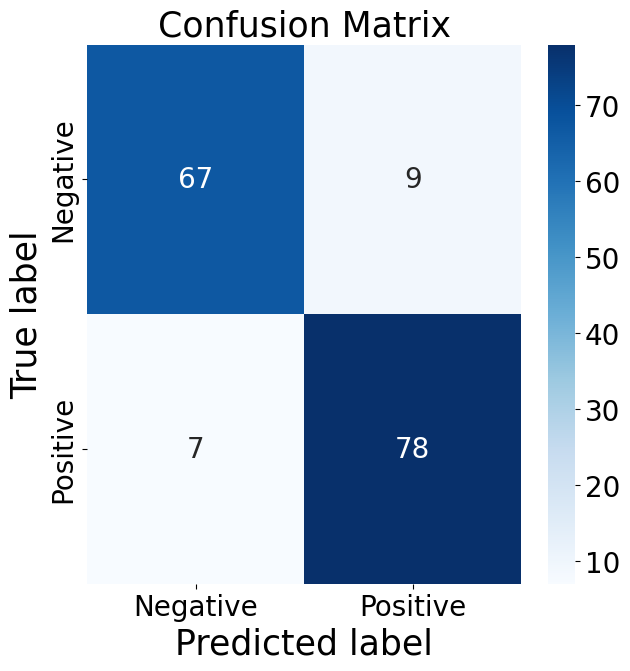

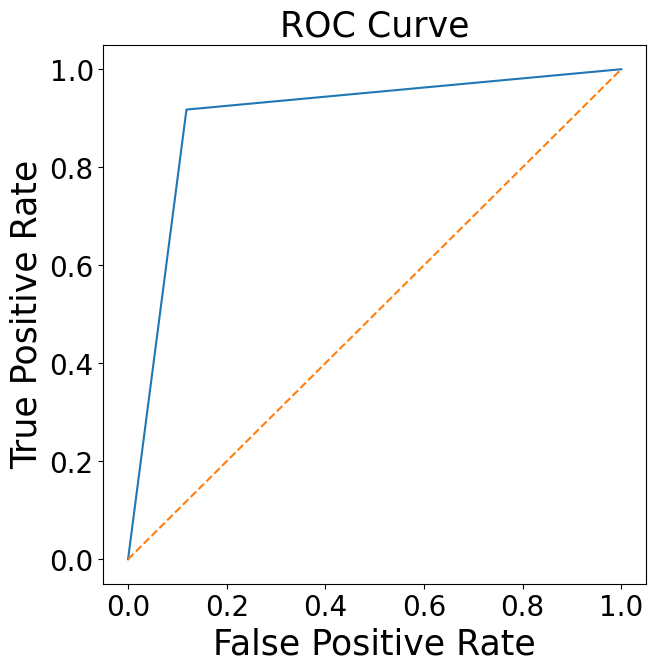

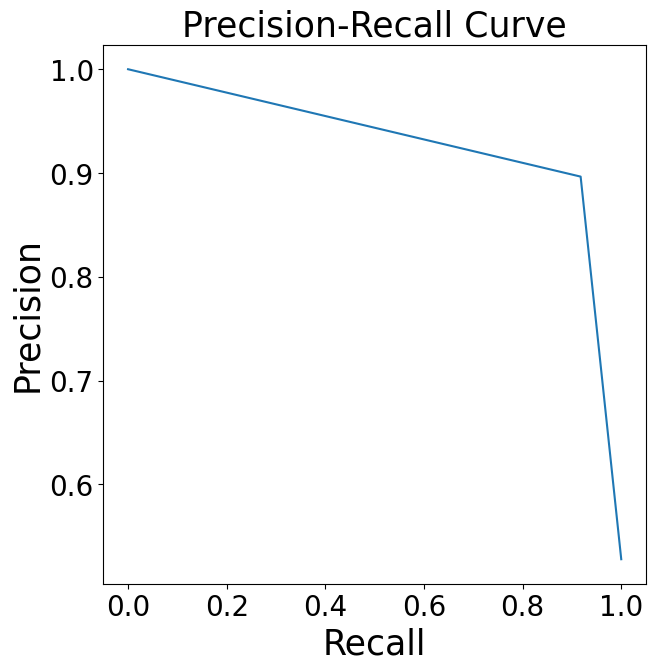

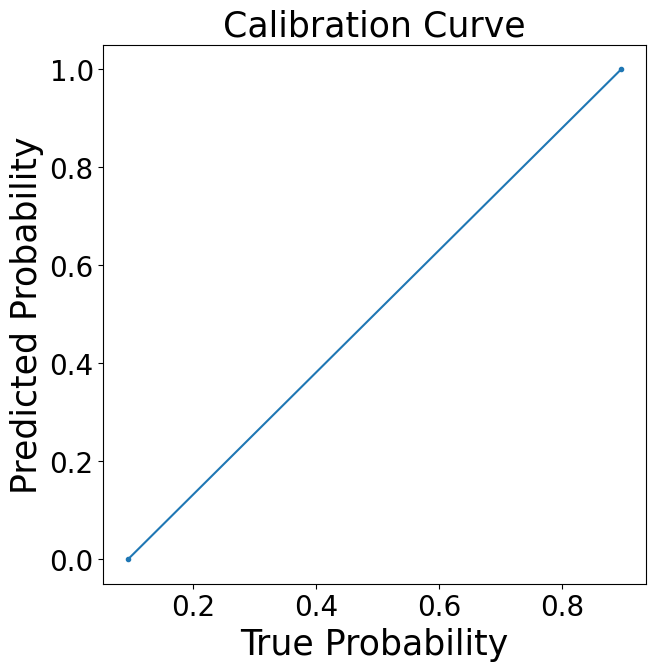

AUC-ROC score: 0.8996130030959751


In [183]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# Plot the precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Plot the calibration curve
true_prob, pred_prob = calibration_curve(y_test, y_pred, n_bins=10)
plt.plot(true_prob, pred_prob, marker='.')
plt.xlabel('True Probability')
plt.ylabel('Predicted Probability')
plt.title('Calibration Curve')
plt.show()

# Calculate the AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)
print('AUC-ROC score:', auc_roc)

In [184]:
import numpy as np

# Get feature importances
importance = logreg.coef_[0]

# Sort feature importances in descending order
indices = np.argsort(abs(importance))[::-1]

print("Most Important Variables:")

# Print feature importances
for i in range(X_train.shape[1]):
    print(f"{i+1}. {X_train.columns[indices[i]]}: {importance[indices[i]]}")

Most Important Variables:
1. OpponentFourthDownConversions: 1.3129408186704927
2. OpponentFourthDownAttempts: -1.0964603972449714
3. OpponentPassingCompletions: 1.0898984490191934
4. OpponentPassingYardsPerAttempt: 0.9384539318348487
5. FourthDownAttempts: 0.8959980984501299
6. OpponentThirdDownConversions: 0.8332973986487614
7. neutral: -0.7409237696404627
8. OpponentRedZoneAttempts: 0.7201833040260968
9. OpponentFumbles: -0.6496353809750124
10. Fumbles: 0.6131482971543464
11. Punts: 0.5059499288770757
12. quarter: 0.48792571415834773
13. TimesSackedYards: 0.47102581905213625
14. OpponentPassingAttempts: -0.46706269428866654
15. OpponentSackYards: -0.4661997967781725
16. OpponentSacks: -0.44686168707370405
17. OpponentFumblesForced: -0.4252232857033045
18. TurnoverDifferential: -0.415309327675389
19. OpponentTurnoverDifferential: 0.4153093276654802
20. OpponentFumblesRecovered: 0.3987492868346183
21. OpponentPunts: -0.3673908692187964
22. OpponentRushingYardsPerAttempt: 0.351472624085

# *Away Team Prediction - Logistic Classification*

In [185]:
#split the data into training and testing
X = NFLmodeldata1.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName','BetOutcome','HomeTeamCover','AwayTeamCover'],axis=1)
y = NFLmodeldata1['HomeTeamCover']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [186]:
# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = logreg.predict(X_test)

In [187]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.9006211180124224
Precision: 0.900731101630652
Recall: 0.9006211180124224
F1 Score: 0.9005363763301072


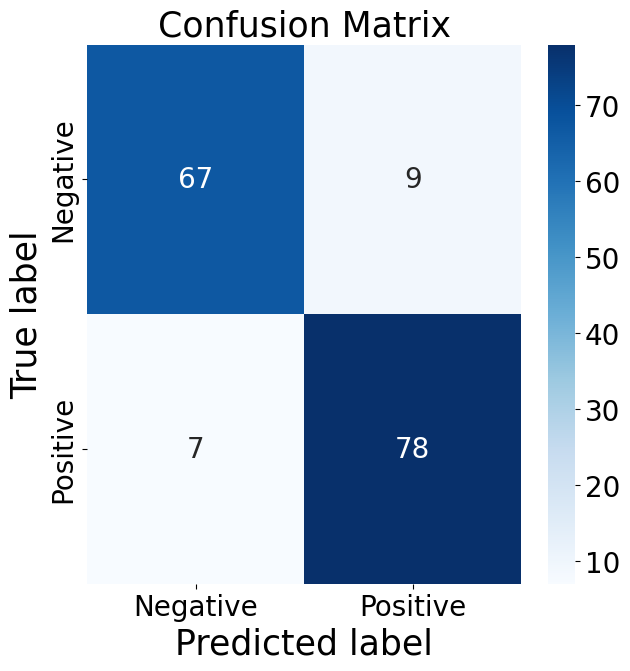

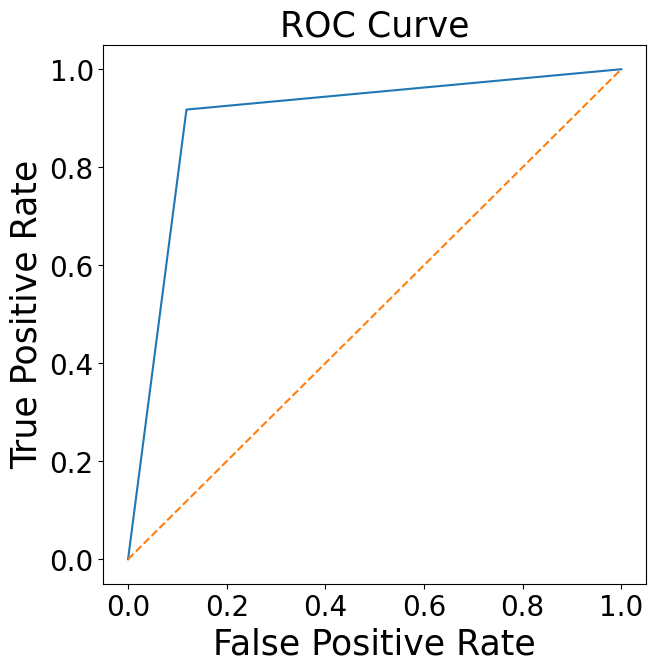

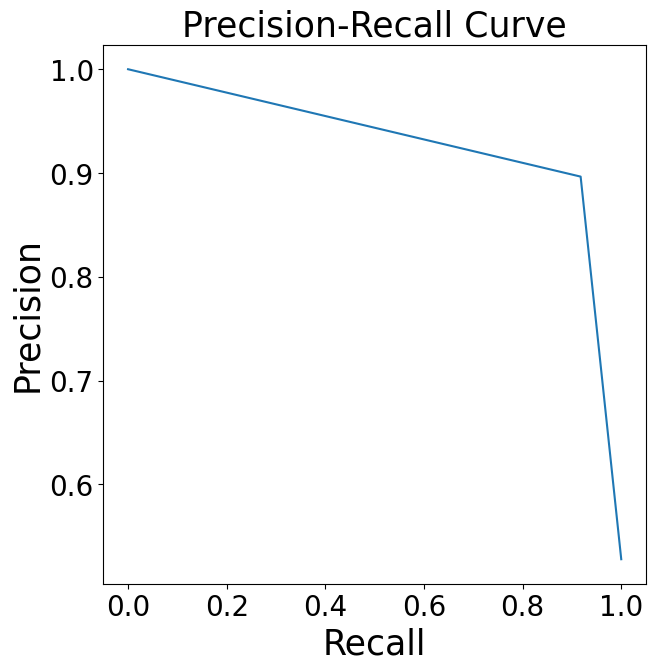

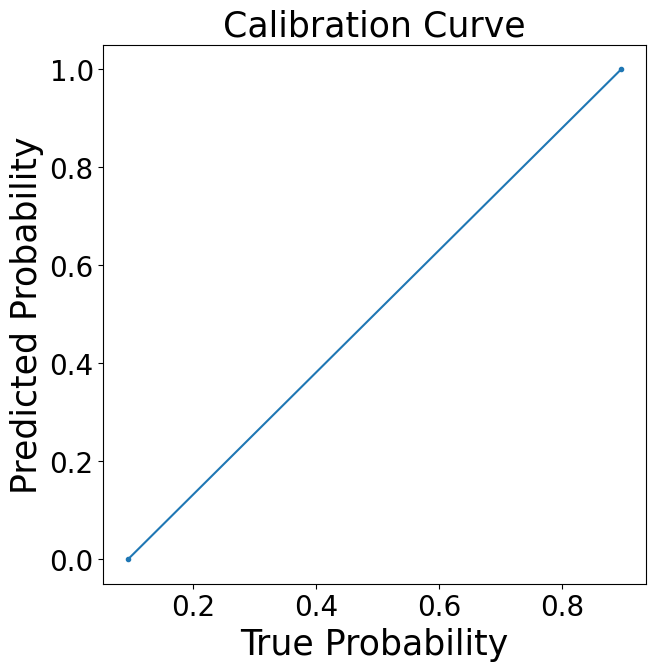

AUC-ROC score: 0.8996130030959751


In [188]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# Plot the precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Plot the calibration curve
true_prob, pred_prob = calibration_curve(y_test, y_pred, n_bins=10)
plt.plot(true_prob, pred_prob, marker='.')
plt.xlabel('True Probability')
plt.ylabel('Predicted Probability')
plt.title('Calibration Curve')
plt.show()

# Calculate the AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)
print('AUC-ROC score:', auc_roc)

In [189]:
# Get feature importances
importance = logreg.coef_[0]

# Sort feature importances in descending order
indices = np.argsort(abs(importance))[::-1]

print("Most Important Variables:")

# Print feature importances
for i in range(X_train.shape[1]):
    print(f"{i+1}. {X_train.columns[indices[i]]}: {importance[indices[i]]}")

Most Important Variables:
1. OpponentFourthDownConversions: 1.3129408186704927
2. OpponentFourthDownAttempts: -1.0964603972449714
3. OpponentPassingCompletions: 1.0898984490191934
4. OpponentPassingYardsPerAttempt: 0.9384539318348487
5. FourthDownAttempts: 0.8959980984501299
6. OpponentThirdDownConversions: 0.8332973986487614
7. neutral: -0.7409237696404627
8. OpponentRedZoneAttempts: 0.7201833040260968
9. OpponentFumbles: -0.6496353809750124
10. Fumbles: 0.6131482971543464
11. Punts: 0.5059499288770757
12. quarter: 0.48792571415834773
13. TimesSackedYards: 0.47102581905213625
14. OpponentPassingAttempts: -0.46706269428866654
15. OpponentSackYards: -0.4661997967781725
16. OpponentSacks: -0.44686168707370405
17. OpponentFumblesForced: -0.4252232857033045
18. TurnoverDifferential: -0.415309327675389
19. OpponentTurnoverDifferential: 0.4153093276654802
20. OpponentFumblesRecovered: 0.3987492868346183
21. OpponentPunts: -0.3673908692187964
22. OpponentRushingYardsPerAttempt: 0.351472624085

# *Over Under Prediction - Logisitic Regression*

In [190]:
#split the data into training and testing
X = NFLmodeldata1.drop(['HomeTeamScore','TotalScore_x','OpponentScore','DateTime','AwayTeamName','HomeTeamName','BetOutcome','HomeTeamCover','AwayTeamCover'],axis=1)
y = NFLmodeldata1['BetOutcome']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1234)

In [191]:
# Train a logistic regression model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = logreg.predict(X_test)

In [192]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

Accuracy: 0.8819875776397516
Precision: 0.8828193807240428
Recall: 0.8819875776397516
F1 Score: 0.8820971146369534


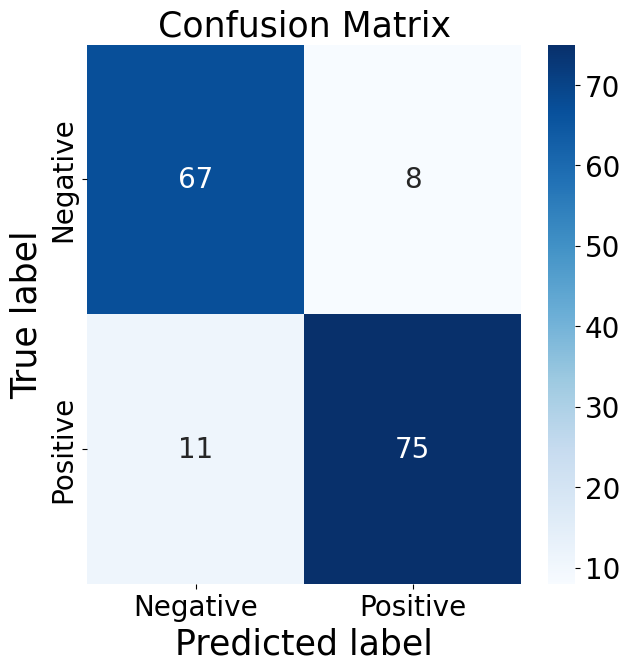

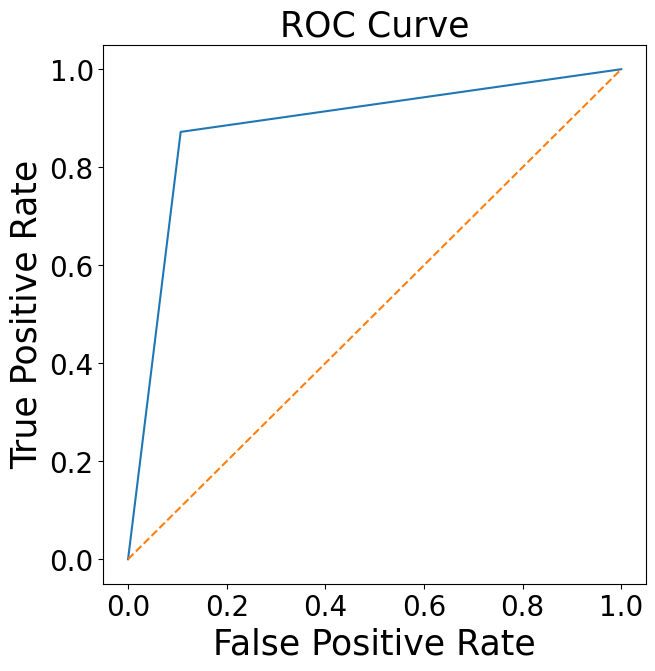

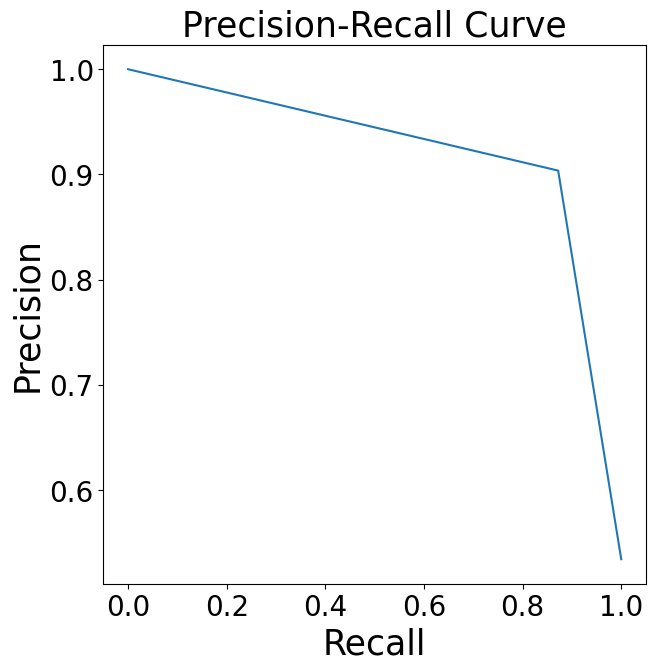

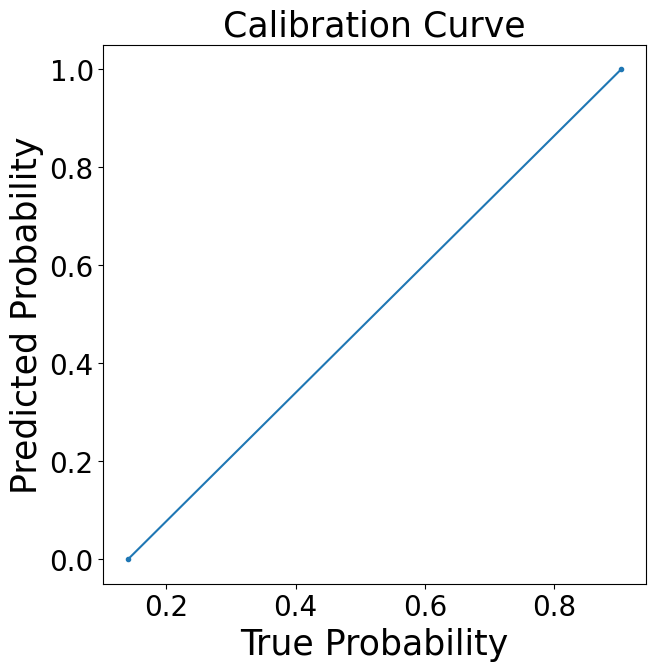

AUC-ROC score: 0.8827131782945736


In [193]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# Plot the precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# Plot the calibration curve
true_prob, pred_prob = calibration_curve(y_test, y_pred, n_bins=10)
plt.plot(true_prob, pred_prob, marker='.')
plt.xlabel('True Probability')
plt.ylabel('Predicted Probability')
plt.title('Calibration Curve')
plt.show()

# Calculate the AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)
print('AUC-ROC score:', auc_roc)

In [194]:
# Get feature importances
importance = logreg.coef_[0]

# Sort feature importances in descending order
indices = np.argsort(abs(importance))[::-1]

print("Most Important Variables:")

# Print feature importances
for i in range(X_train.shape[1]):
    print(f"{i+1}. {X_train.columns[indices[i]]}: {importance[indices[i]]}")

Most Important Variables:
1. RedZoneAttempts: -0.8507289839567034
2. PassingYardsPerAttempt: 0.7439662142901757
3. ThirdDownConversions: 0.7329570830870076
4. OpponentPassingYardsPerAttempt: -0.7278382421140147
5. FumblesRecovered: 0.5841599197002649
6. Punts: 0.583817574463782
7. OpponentFumblesRecovered: 0.5248679771209959
8. OpponentPunts: 0.4957252858554655
9. FumblesForced: 0.4804004433373376
10. TimesSackedYards: -0.4684124338025921
11. OverUnder: 0.4187116816492408
12. neutral: 0.4172768996062919
13. OpponentOffensiveYardsPerPlay: -0.40957932969291444
14. OpponentSacks: 0.4058248937557484
15. OpponentSackYards: 0.39560118769076447
16. OpponentFumbles: -0.3941814429579128
17. ThirdDownAttempts: -0.39142129552947985
18. OpponentRushingYardsPerAttempt: 0.39085249884587175
19. OpponentRedZoneAttempts: -0.3532143887312558
20. OpponentGiveaways: -0.3526963162236034
21. Takeaways: -0.35269631620928105
22. OpponentTimesSacked: 0.3380009502524854
23. OpponentPenalties: 0.3336448575787700